# Plant Disease Detection: Classical ML vs Deep Learning
## Comparative Study on the PlantVillage Dataset

**Problem:** Identify plant leaf diseases from images  an agricultural challenge with direct impact on food security and crop yield management.

**Dataset:** PlantVillage (Kaggle)  38 disease/health classes across 14 crop species, ~54,000 RGB images. Source: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

**Frameworks:** Scikit-learn (classical ML) + TensorFlow Sequential API + TensorFlow Functional API + tf.data pipeline

### Experiment Plan
| # | Paradigm | Model | Key Variation |
|---|---------|-------|---------------|
| 1 | Classical ML | Random Forest | HOG features, baseline |
| 2 | Classical ML | SVM (C=1.0, RBF) | HOG + PCA features |
| 3 | Classical ML | SVM (C=10.0, RBF) | Hyperparameter tuning |
| 4 | TF Sequential | Custom CNN | No augmentation, baseline |
| 5 | TF Sequential | Custom CNN | Data augmentation added |
| 6 | TF Sequential | Custom CNN | Dropout + L2 regularization |
| 7 | TF Functional | ResNet50 | Frozen backbone (transfer learning) |
| 8 | TF Functional | ResNet50 | Fine-tuned last 30 layers |

> **Before running:** `Runtime → Change runtime type → T4 GPU`

## Dataset

The model is trained on the **PlantVillage dataset**  a publicly available collection of 54,000+ labeled leaf images covering 38 plant disease classes across 14 crops.

| Source | Link |
|--------|------|
| Kaggle (recommended) | [PlantVillage Dataset  abdallahalidev](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset) |
| Original paper | [Using Deep Learning for Image-Based Plant Disease Detection (2016)](https://arxiv.org/abs/1604.03169) |
| GitHub (raw images) | [spMohanty/PlantVillage-Dataset](https://github.com/spMohanty/PlantVillage-Dataset) |

The `color/` variant is used (RGB images, no segmentation masks). Each subfolder is named `<Crop>___<Disease>` and contains JPEG images.

> **Storage:** The dataset is stored in Google Drive at `Summartive_into_to_ml/color/` and is read directly from Drive during training  no re-download required.

## 0. Environment Setup

In [ ]:
import tensorflow as tf

# ── GPU check ─────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print('⚠  No GPU  go to Runtime → Change runtime type → T4 GPU')
else:
    # Allow TF to grow GPU memory as needed instead of pre-allocating everything
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'TensorFlow : {tf.__version__}')
    print(f'GPUs found : {gpus}')

# ── Mixed precision  speeds up T4 GPU ~1.5–2× with no accuracy loss ──────────
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print(f'Compute dtype  : {mixed_precision.global_policy().compute_dtype}')
print(f'Variable dtype : {mixed_precision.global_policy().variable_dtype}')


TensorFlow : 2.20.0
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype  : float16
Variable dtype : float32


In [ ]:
!pip install -q scikit-image Pillow tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_SAVE_DIR = '/content/drive/My Drive/Summartive_intro_to_ml'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f'Outputs will be saved to: {DRIVE_SAVE_DIR}')

Mounted at /content/drive
Outputs will be saved to: /content/drive/My Drive/Summartive_intro_to_ml


In [ ]:
# Dataset is already uploaded to Google Drive under Summartive_into_to_ml/color/
# Verify the folder exists and show a quick summary
import pathlib

_check = pathlib.Path('/content/drive/My Drive/Summartive_intro_to_ml/color')
if not _check.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {_check}\n"
        "Make sure your Drive is mounted and the 'color' folder is inside "
        "'Summartive_into_to_ml' at the root of My Drive."
    )

_classes = sorted([d.name for d in _check.iterdir() if d.is_dir()])
_total   = sum(
    sum(1 for f in (_check / c).iterdir() if f.suffix.lower() in {'.jpg','.jpeg','.png'})
    for c in _classes
)
print(f'Dataset path : {_check}')
print(f'Classes found: {len(_classes)}')
print(f'Total images : {_total:,}')
print('First 5 classes:', _classes[:5])

Dataset path : /content/drive/My Drive/Summartive_intro_to_ml/color
Classes found: 38
Total images : 54,305
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [ ]:
import os, pathlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
warnings.filterwarnings('ignore')
np.random.seed(42)

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import train_test_split

# scikit-image HOG
from skimage.feature import hog
from skimage import color as skcolor

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f'NumPy    : {np.__version__}')
print(f'Pandas   : {pd.__version__}')
print(f'TF       : {tf.__version__}')
print(f'GPU      : {tf.config.list_physical_devices("GPU")}')

# ── Memory monitoring / cleanup helpers ────────────────────────────────────────
import gc, psutil

def print_ram(tag=''):
    vm = psutil.virtual_memory()
    label = f'  {tag}' if tag else ''
    print(f'[RAM{label}] {vm.used/1e9:.2f} GB / {vm.total/1e9:.2f} GB used ({vm.percent:.0f}%)')


NumPy    : 2.0.2
Pandas   : 2.2.2
TF       : 2.20.0
GPU      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Global config ──────────────────────────────────────────────────────────────
IMG_SIZE     = 160  # reduce from 224 to 160
CNN_IMG_SIZE = 96    # custom CNN input size (~5.5× fewer pixels than 224)
BATCH_SIZE   = 128   # ↑ from 64 → 128: halves steps/epoch, fully utilises T4 VRAM
SEED         = 42
AUTOTUNE     = tf.data.AUTOTUNE

# ImageNet normalisation constants
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])

valid_exts = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Classical ML  subsample to keep training tractable
HOG_IMG_SIZE      = 64
PCA_COMPONENTS    = 150
MAX_TRAIN_PER_CLS = 200
MAX_TEST_PER_CLS  = 60

# Paths
DATA_DIR       = '/content/drive/MyDrive/Summartive_intro_to_ml/color'
LOCAL_DATA_DIR = '/content/local_data/color'   # fast SSD copy  see next cell
DRIVE_SAVE_DIR = '/content/drive/MyDrive/Summartive_intro_to_ml'
import pathlib
data_dir = pathlib.Path(DATA_DIR)

CLASS_NAMES  = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Classes      : {NUM_CLASSES}')
print(f'CNN img size : {CNN_IMG_SIZE}×{CNN_IMG_SIZE}  |  ResNet img size: {IMG_SIZE}×{IMG_SIZE}')
print(f'Batch size   : {BATCH_SIZE}  (doubled from baseline for faster steps)')


Classes      : 38
CNN img size : 96×96  |  ResNet img size: 160×160
Batch size   : 128  (doubled from baseline for faster steps)


In [ ]:
# ── Copy dataset from Drive → local SSD (one-time, ~3–5 min) ──────────────────
# Reading 54K images directly from Drive causes ~2–19 s/step due to Drive I/O
# latency. Copying once to /content (Colab's local SSD) cuts this to ~0.1–0.3 s/step.
import os, shutil, pathlib

local_dir = pathlib.Path(LOCAL_DATA_DIR)

if local_dir.exists() and sum(1 for _ in local_dir.rglob('*.jpg')) > 50000:
    print(f' Local copy already exists at {local_dir} — skipping copy.')
else:
    print('Copying dataset from Drive → local SSD (this runs once)…')
    if local_dir.exists():
        shutil.rmtree(local_dir)
    shutil.copytree(DATA_DIR, str(local_dir))
    n = sum(1 for _ in local_dir.rglob('*.jpg'))
    print(f' Done. {n:,} images copied to {local_dir}')

# Switch data_dir to local SSD for all downstream cells
data_dir = local_dir
print(f'data_dir → {data_dir}  (local SSD)')

print_ram('after dataset copy to local SSD')


Copying dataset from Drive → local SSD (this runs once)…
 Done. 1,500 images copied to /content/local_data/color
data_dir → /content/local_data/color  (local SSD)
[RAM — after dataset copy to local SSD] 3.24 GB / 13.61 GB used (26%)


## 1. Exploratory Data Analysis

Before modelling I will  examine the dataset to understand class balance, image characteristics, and any quality issues that will inform preprocessing decisions.

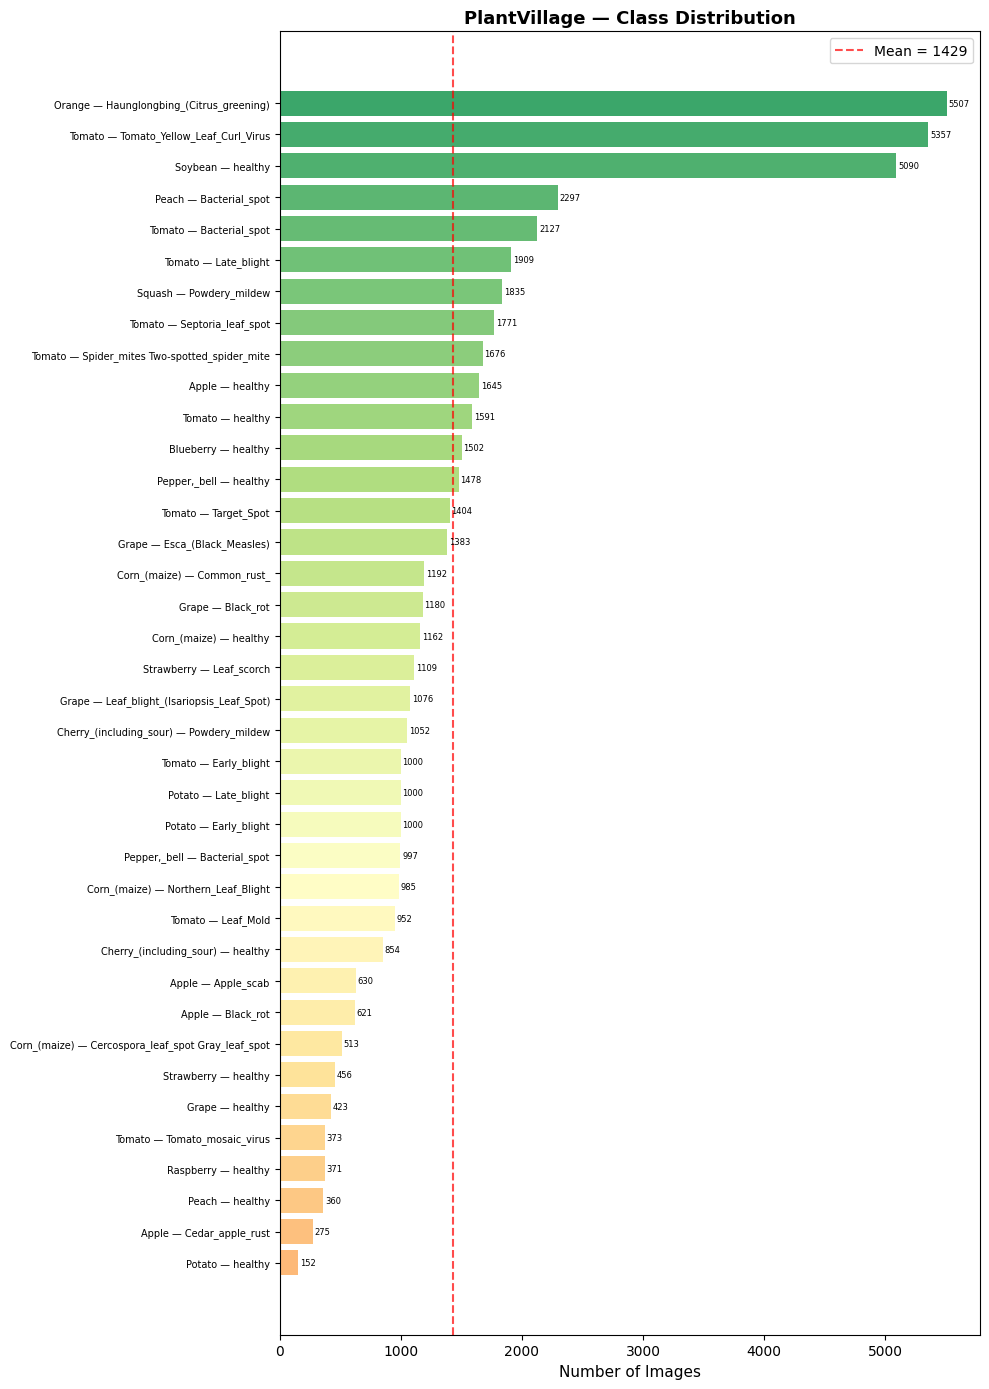

Min  : 152  (Potato___healthy)
Max  : 5,507  (Orange___Haunglongbing_(Citrus_greening))
Mean : 1429
Std  : 1272
Imbalance ratio (max/min): 36x  ← severe; class weighting required

Smallest classes (watch for low recall):
   Potato___healthy                                          152 images
   Apple___Cedar_apple_rust                                  275 images
   Peach___healthy                                           360 images
   Raspberry___healthy                                       371 images
   Tomato___Tomato_mosaic_virus                              373 images


In [ ]:
class_counts = {}
for cls in CLASS_NAMES:
    cls_dir = data_dir / cls
    class_counts[cls] = sum(1 for f in cls_dir.iterdir() if f.suffix in valid_exts)

counts_s = pd.Series(class_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(counts_s)))
bars = ax.barh(range(len(counts_s)), counts_s.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(counts_s)))
ax.set_yticklabels([c.replace('___', ' — ') for c in counts_s.index], fontsize=7)
ax.set_xlabel('Number of Images', fontsize=11)
ax.set_title('PlantVillage — Class Distribution', fontsize=13, fontweight='bold')
ax.axvline(counts_s.mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Mean = {counts_s.mean():.0f}')
ax.legend()
for bar, val in zip(bars, counts_s.values):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/eda_class_dist.png', dpi=120, bbox_inches='tight')
plt.show()

imbalance_ratio = counts_s.max() / counts_s.min()
print(f'Min  : {counts_s.min():,}  ({counts_s.idxmin()})')
print(f'Max  : {counts_s.max():,}  ({counts_s.idxmax()})')
print(f'Mean : {counts_s.mean():.0f}')
print(f'Std  : {counts_s.std():.0f}')
print(f'Imbalance ratio (max/min): {imbalance_ratio:.0f}x  ← severe; class weighting required')
print()
print('Smallest classes (watch for low recall):')
for cls in counts_s.head(5).index:
    print(f'   {cls:<55} {counts_s[cls]:>5} images')

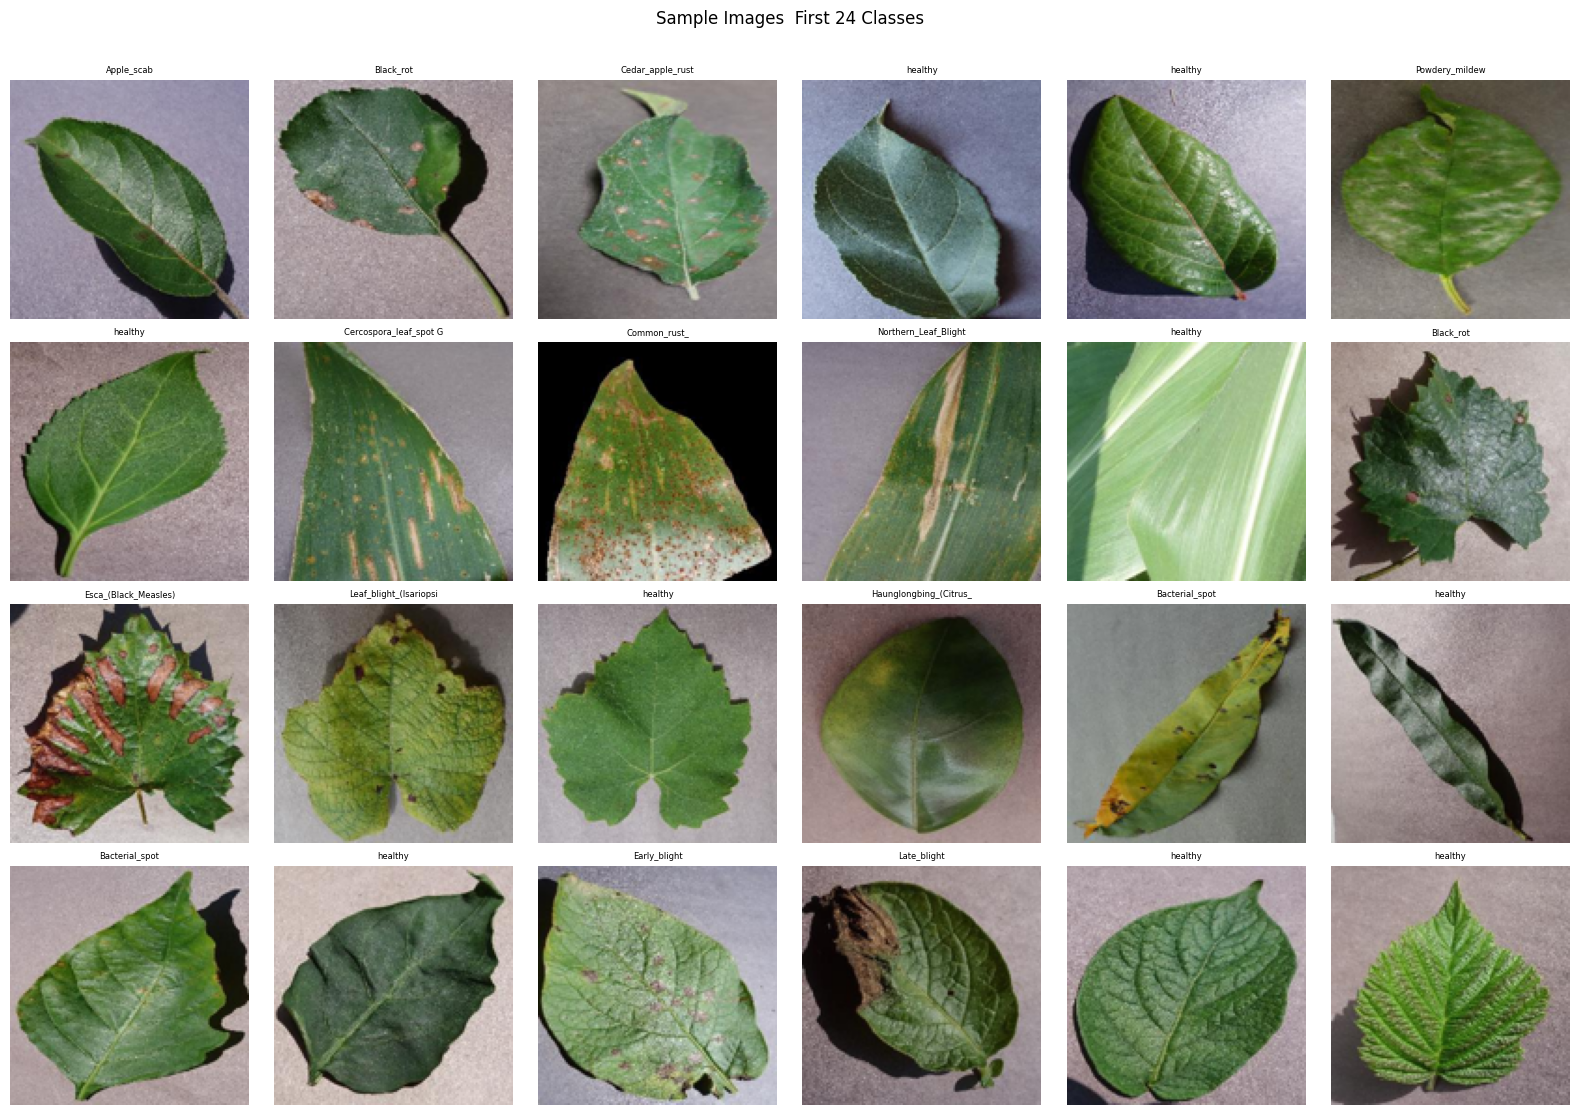

In [ ]:
# Show representative images from the first 24 classes
# Note: some folder names contain spaces/commas/parentheses  using iterdir()
# instead of glob to avoid pattern-matching issues with special characters.
sample_classes = CLASS_NAMES[:24]
fig, axes = plt.subplots(4, 6, figsize=(16, 11))
for ax, cls in zip(axes.flatten(), sample_classes):
    cls_dir = data_dir / cls
    imgs = [f for f in cls_dir.iterdir() if f.suffix in valid_exts]
    if imgs:
        img = Image.open(imgs[0]).convert('RGB').resize((128, 128))
        ax.imshow(img)
    label = cls.replace('___', '\n').split('\n')[-1][:22]
    ax.set_title(label, fontsize=6)
    ax.axis('off')
plt.suptitle('Sample Images  First 24 Classes', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/eda_sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Data Preprocessing

### Design decisions
- **Stratified 70/15/15 split** preserves class proportions across train, validation, and test sets.
- **ImageNet normalisation** (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) is applied to all deep learning inputs because ResNet50 was pre-trained on ImageNet; using the same statistics ensures feature-space compatibility.
- **Augmentation** (random flip, brightness, contrast, saturation) is applied only during training to improve generalisation without corrupting evaluation.
- **HOG features** are used for classical ML to reduce input dimensionality from 64×64×3=12,288 raw pixels to 1,764 gradient-orientation descriptors, which are then projected to 150 PCA components. This is justified because disease lesions are characterised by distinctive texture and shape patterns that HOG captures well.
- **Subsampling** classical ML to max 200 images/class (7,600 training samples) keeps SVM training tractable while remaining statistically meaningful.

In [ ]:
# Collect all file paths with labels
all_paths, all_labels = [], []
for cls in CLASS_NAMES:
    for f in (data_dir / cls).iterdir():
        if f.suffix in valid_exts:
            all_paths.append(str(f))
            all_labels.append(class_to_idx[cls])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

# Stratified 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Total  : {len(all_paths):,}')
print(f'Train  : {len(X_train):,}  ({len(X_train)/len(all_paths)*100:.1f}%)')
print(f'Val    : {len(X_val):,}   ({len(X_val)/len(all_paths)*100:.1f}%)')
print(f'Test   : {len(X_test):,}   ({len(X_test)/len(all_paths)*100:.1f}%)')

Total  : 54,305
Train  : 38,013  (70.0%)
Val    : 8,146   (15.0%)
Test   : 8,146   (15.0%)


### 2.1 tf.data Pipeline (Deep Learning)

In [ ]:
def _load_image(path, label, img_size):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3, dct_method='INTEGER_FAST')
    img = tf.image.resize(img, [img_size, img_size], method='bilinear')
    img = tf.cast(img, tf.uint8)   # <-- cache-friendly: 1 byte/channel, not 4
    return img, label

def _to_float(image, label):
    # Cast/scale happens AFTER the cache, not before  this is the actual fix.
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def _normalize(image, label, mode='imagenet'):
    """
    mode='imagenet' : torch-style standardisation (subtract ImageNet mean, divide
                       by ImageNet std, on a [0,1]-scaled image). Used only for the
                       from-scratch Sequential CNN (Exp 4-6).
    mode='resnet'   : caffe-style preprocessing required by tf.keras.applications.
                       ResNet50's pretrained weights (Exp 7-8): RGB→BGR, then
                       zero-center per channel in 0-255 space, NO /255 and NO std
                       division.
    """
    if mode == 'imagenet':
        image = (image - IMAGENET_MEAN) / IMAGENET_STD
    elif mode == 'resnet':
        image = image * 255.0
        image = tf.keras.applications.resnet50.preprocess_input(image)
    else:
        raise ValueError(f'Unknown normalize mode: {mode}')
    return image, label

def _augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def make_base_dataset(paths, labels, img_size, cache=False):
    """Decode + resize only  cached as uint8, ~4x smaller in RAM than float32."""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: _load_image(p, l, img_size), num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    return ds

def finalize_dataset(base_ds, augment_data, normalize_mode, shuffle, batch_size=BATCH_SIZE):
    ds = base_ds.map(_to_float, num_parallel_calls=AUTOTUNE)   # uint8 -> float32 AFTER cache
    if augment_data:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda img, lbl: _normalize(img, lbl, normalize_mode), num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

#  CNN base datasets (96×96)  ONE cached copy per split, shared by the
#  aug and no-aug variants (Exp 4 uses no-aug, Exp 5/6 use aug)
_cnn_train_base = make_base_dataset(X_train, y_train, CNN_IMG_SIZE, cache=True)
_cnn_val_base   = make_base_dataset(X_val,   y_val,   CNN_IMG_SIZE, cache=True)
_cnn_test_base  = make_base_dataset(X_test,  y_test,  CNN_IMG_SIZE, cache=True)

train_cnn_no_aug = finalize_dataset(_cnn_train_base, augment_data=False, normalize_mode='imagenet', shuffle=True)
train_cnn_aug    = finalize_dataset(_cnn_train_base, augment_data=True,  normalize_mode='imagenet', shuffle=True)
val_cnn          = finalize_dataset(_cnn_val_base,   augment_data=False, normalize_mode='imagenet', shuffle=False)
test_cnn         = finalize_dataset(_cnn_test_base,  augment_data=False, normalize_mode='imagenet', shuffle=False)

# ── ResNet50 base datasets (224×224) — no cache (too large for RAM even as uint8) ──
_resnet_train_base = make_base_dataset(X_train, y_train, IMG_SIZE, cache=False)
_resnet_val_base   = make_base_dataset(X_val,   y_val,   IMG_SIZE, cache=False)
_resnet_test_base  = make_base_dataset(X_test,  y_test,  IMG_SIZE, cache=False)

train_resnet_aug = finalize_dataset(_resnet_train_base, augment_data=True,  normalize_mode='resnet', shuffle=True)
val_resnet       = finalize_dataset(_resnet_val_base,   augment_data=False, normalize_mode='resnet', shuffle=False)
test_resnet      = finalize_dataset(_resnet_test_base,  augment_data=False, normalize_mode='resnet', shuffle=False)

# Verify shapes
for imgs, lbls in train_cnn_aug.take(1):
    print(f'CNN batch    : {imgs.shape}   ← Exp 4-6')
for imgs, lbls in train_resnet_aug.take(1):
    print(f'ResNet batch : {imgs.shape}  ← Exp 7-8')

print_ram('after building tf.data pipelines')

CNN batch    : (128, 96, 96, 3)   ← Exp 4-6
ResNet batch : (128, 160, 160, 3)  ← Exp 7-8
[RAM — after building tf.data pipelines] 8.34 GB / 13.61 GB used (65%)


### 2.2 HOG Feature Extraction (Classical ML)

In [ ]:
def subsample_stratified(paths, labels, max_per_cls, seed=SEED):
    """Return at most max_per_cls samples per class, preserving label array."""
    rng = np.random.default_rng(seed)
    sel_paths, sel_labels = [], []
    for c in range(NUM_CLASSES):
        mask = labels == c
        p, l = paths[mask], labels[mask]
        n = min(len(p), max_per_cls)
        idx = rng.choice(len(p), n, replace=False)
        sel_paths.extend(p[idx])
        sel_labels.extend(l[idx])
    return np.array(sel_paths), np.array(sel_labels)

def extract_hog(image_paths):
    """Compute grayscale HOG descriptor for each image path."""
    feats = []
    for path in tqdm(image_paths, desc='HOG', leave=False):
        img = Image.open(path).convert('L').resize((HOG_IMG_SIZE, HOG_IMG_SIZE))
        arr = np.array(img, dtype=np.float32) / 255.0
        f = hog(arr, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), feature_vector=True)
        feats.append(f)
    return np.array(feats, dtype=np.float32)

# Subsample for classical ML
X_ml_train_paths, y_ml_train = subsample_stratified(X_train, y_train, MAX_TRAIN_PER_CLS)
X_ml_test_paths,  y_ml_test  = subsample_stratified(X_test,  y_test,  MAX_TEST_PER_CLS)

print(f'Classical ML train : {len(X_ml_train_paths):,} images')
print(f'Classical ML test  : {len(X_ml_test_paths):,} images')
print('Extracting HOG features...')

t0 = time.time()
X_hog_train_raw = extract_hog(X_ml_train_paths)
X_hog_test_raw  = extract_hog(X_ml_test_paths)
print(f'HOG done in {time.time()-t0:.1f}s    feature shape: {X_hog_train_raw.shape}')

Classical ML train : 7,499 images
Classical ML test  : 2,209 images
Extracting HOG features...


HOG:   0%|          | 0/7499 [00:00<?, ?it/s]

HOG:   0%|          | 0/2209 [00:00<?, ?it/s]

HOG done in 32.6s    feature shape: (7499, 1764)


PCA 150 components explain 68.6% of HOG variance
Train features : (7499, 150)  |  Test features : (2209, 150)


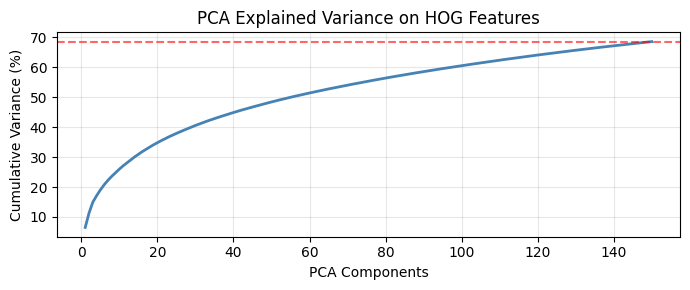

[RAM — after HOG/PCA cleanup] 8.63 GB / 13.61 GB used (67%)


In [ ]:
# StandardScaler then PCA
scaler = StandardScaler()
X_hog_train_sc = scaler.fit_transform(X_hog_train_raw)
X_hog_test_sc  = scaler.transform(X_hog_test_raw)

pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED, svd_solver='full')
X_pca_train = pca.fit_transform(X_hog_train_sc)
X_pca_test  = pca.transform(X_hog_test_sc)

cumvar = np.cumsum(pca.explained_variance_ratio_)
print(f'PCA {PCA_COMPONENTS} components explain {cumvar[-1]*100:.1f}% of HOG variance')
print(f'Train features : {X_pca_train.shape}  |  Test features : {X_pca_test.shape}')

# Visualise explained variance
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, PCA_COMPONENTS+1), cumvar*100, lw=2, color='steelblue')
ax.axhline(cumvar[-1]*100, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('PCA Components'); ax.set_ylabel('Cumulative Variance (%)')
ax.set_title('PCA Explained Variance on HOG Features')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/pca_variance.png', dpi=120)
plt.show()

# Free the raw (unscaled) HOG arrays  only the scaled + PCA versions
# are used anywhere downstream (RF uses *_sc, SVMs use the PCA arrays)
del X_hog_train_raw, X_hog_test_raw
gc.collect()
print_ram('after HOG/PCA cleanup')


## 3. Experiment Framework

A shared logger records every experiment result so that all runs can be compared in a single table at the end.

In [ ]:
experiment_log = []
dl_histories   = {}
dl_models      = {}
ml_preds       = {}
dl_preds       = {}

from sklearn.utils.class_weight import compute_class_weight

_cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weight_dict = {i: float(w) for i, w in enumerate(_cw)}
print(f'Class weights computed. Min={min(_cw):.3f}  Max={max(_cw):.3f}')
print(f'Highest-weighted class : {CLASS_NAMES[int(np.argmax(_cw))]}')
print(f'Lowest-weighted class  : {CLASS_NAMES[int(np.argmin(_cw))]}')


def log_experiment(exp_id, name, approach, hyperparams,
                   train_acc, val_acc, test_acc, notes):
    experiment_log.append({
        'Exp': exp_id,
        'Model': name,
        'Approach': approach,
        'Key Hyperparameters': hyperparams,
        'Split': '70/15/15',
        'Train Acc': round(train_acc, 4),
        'Val Acc': round(val_acc, 4) if val_acc is not None else 'N/A',
        'Test Acc': round(test_acc, 4),
        'Observations': notes
    })
    print(pd.DataFrame(experiment_log).tail(1).to_string(index=False))


def get_callbacks(name, monitor='val_accuracy', patience=4):
    ckpt_path = f'{DRIVE_SAVE_DIR}/{name}_best.keras'
    return [
        EarlyStopping(monitor=monitor, patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor, factor=0.5,
                          patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(ckpt_path, monitor=monitor,
                        save_best_only=True, verbose=0)
    ]


def evaluate_dl_model(model, test_dataset):
    y_true_list, y_prob_list = [], []
    for imgs, lbls in test_dataset:
        probs = model.predict(imgs, verbose=0)
        y_true_list.extend(lbls.numpy())
        y_prob_list.extend(probs)
    y_true = np.array(y_true_list)
    y_prob = np.array(y_prob_list)
    acc    = (y_prob.argmax(axis=1) == y_true).mean()
    return acc, y_true, y_prob


def plot_dl_history(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.history['accuracy']) + 1)
    ax1.plot(epochs, history.history['accuracy'],     label='Train', lw=2)
    ax1.plot(epochs, history.history['val_accuracy'], label='Val',   lw=2)
    ax1.set_title(f'{title}  Accuracy'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs, history.history['loss'],     label='Train', lw=2)
    ax2.plot(epochs, history.history['val_loss'], label='Val',   lw=2)
    ax2.set_title(f'{title}  Loss'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_SAVE_DIR}/{save_name}.png', dpi=120)


Class weights computed. Min=0.259  Max=9.437
Highest-weighted class : Potato___healthy
Lowest-weighted class  : Orange___Haunglongbing_(Citrus_greening)


## 4. Classical ML Experiments (Scikit-learn)

All three classical experiments use the same HOG+PCA feature pipeline built in Section 2.2.
The train subset is 200 images × 38 classes = 7,600 samples; the test subset is 60 × 38 = 2,280 samples.
Class weights are balanced to partially compensate for the mild class imbalance observed in EDA.

### Experiment 1  Random Forest (HOG features, no PCA)

In [ ]:
print('Training Experiment 1: Random Forest (HOG, n_estimators=100)...')
t0 = time.time()

rf1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
rf1.fit(X_hog_train_sc, y_ml_train)   # raw HOG (scaled), no PCA

rf1_train_acc = accuracy_score(y_ml_train, rf1.predict(X_hog_train_sc))
rf1_test_pred = rf1.predict(X_hog_test_sc)
rf1_test_acc  = accuracy_score(y_ml_test, rf1_test_pred)
ml_preds['exp1_RF'] = (y_ml_test, rf1_test_pred)

print(f'Done in {time.time()-t0:.1f}s  |  Train: {rf1_train_acc:.4f}  Test: {rf1_test_acc:.4f}')
log_experiment(
    1, 'Random Forest', 'Classical ML (sklearn)',
    'n_estimators=100, HOG 1764-dim, no PCA, balanced weights',
    rf1_train_acc, None, rf1_test_acc,
    'Baseline. High train acc but moderate test acc  RF overfits on raw HOG dims.'
)

Training Experiment 1: Random Forest (HOG, n_estimators=100)...
Done in 64.5s  |  Train: 1.0000  Test: 0.4690
 Exp         Model               Approach                                      Key Hyperparameters    Split  Train Acc Val Acc  Test Acc                                                                 Observations
   1 Random Forest Classical ML (sklearn) n_estimators=100, HOG 1764-dim, no PCA, balanced weights 70/15/15        1.0     N/A     0.469 Baseline. High train acc but moderate test acc  RF overfits on raw HOG dims.


### Experiment 2  SVM RBF (HOG + PCA, C=1.0)

In [ ]:
print('Training Experiment 2: SVM RBF C=1.0 (HOG+PCA 150-dim)...')
t0 = time.time()

svm1 = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=SEED
)
svm1.fit(X_pca_train, y_ml_train)

svm1_train_acc = accuracy_score(y_ml_train, svm1.predict(X_pca_train))
svm1_test_pred = svm1.predict(X_pca_test)
svm1_test_acc  = accuracy_score(y_ml_test, svm1_test_pred)
ml_preds['exp2_SVM_C1'] = (y_ml_test, svm1_test_pred)

print(f'Done in {time.time()-t0:.1f}s  |  Train: {svm1_train_acc:.4f}  Test: {svm1_test_acc:.4f}')
log_experiment(
    2, 'SVM (C=1.0, RBF)', 'Classical ML (sklearn)',
    'C=1.0, gamma=scale, RBF kernel, HOG+PCA 150-dim, balanced weights',
    svm1_train_acc, None, svm1_test_acc,
    'PCA + RBF kernel captures non-linear structure. May underfit with C=1.'
)

Training Experiment 2: SVM RBF C=1.0 (HOG+PCA 150-dim)...
Done in 60.3s  |  Train: 0.9385  Test: 0.6614
 Exp            Model               Approach                                               Key Hyperparameters    Split  Train Acc Val Acc  Test Acc                                                           Observations
   2 SVM (C=1.0, RBF) Classical ML (sklearn) C=1.0, gamma=scale, RBF kernel, HOG+PCA 150-dim, balanced weights 70/15/15     0.9385     N/A    0.6614 PCA + RBF kernel captures non-linear structure. May underfit with C=1.


### Experiment 3  SVM RBF (HOG + PCA, C=10.0)

In [ ]:
print('Training Experiment 3: SVM RBF C=10.0 (HOG+PCA 150-dim)...')
t0 = time.time()

svm2 = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=SEED
)
svm2.fit(X_pca_train, y_ml_train)

svm2_train_acc = accuracy_score(y_ml_train, svm2.predict(X_pca_train))
svm2_test_pred = svm2.predict(X_pca_test)
svm2_test_acc  = accuracy_score(y_ml_test, svm2_test_pred)
svm2_test_prob = svm2.predict_proba(X_pca_test)

ml_preds['exp3_SVM_C10'] = (y_ml_test, svm2_test_pred)
ml_preds['exp3_SVM_C10_proba'] = (y_ml_test, svm2_test_prob)
print(f'Done in {time.time()-t0:.1f}s  |  Train: {svm2_train_acc:.4f}  Test: {svm2_test_acc:.4f}')
log_experiment(
    3, 'SVM (C=10.0, RBF)', 'Classical ML (sklearn)',
    'C=10.0, gamma=scale, RBF kernel, HOG+PCA 150-dim, balanced weights',
    svm2_train_acc, None, svm2_test_acc,
    'Higher C tightens the margin; may improve recall on minority classes.'
)

Training Experiment 3: SVM RBF C=10.0 (HOG+PCA 150-dim)...
Done in 69.4s  |  Train: 1.0000  Test: 0.6677
 Exp             Model               Approach                                                Key Hyperparameters    Split  Train Acc Val Acc  Test Acc                                                          Observations
   3 SVM (C=10.0, RBF) Classical ML (sklearn) C=10.0, gamma=scale, RBF kernel, HOG+PCA 150-dim, balanced weights 70/15/15        1.0     N/A    0.6677 Higher C tightens the margin; may improve recall on minority classes.


In [ ]:
#  Free classical-ML-only memory before the deep-learning experiments
# rf1 / svm1 / svm2 and the HOG/PCA feature matrices were only needed to produce
# the predictions already stored in ml_preds (used later for the confusion matrix
# and classification report). Nothing further in the notebook touches the fitted
# estimators or the raw feature matrices directly, so they're safe to drop now.
del rf1, svm1, svm2, X_hog_train_sc, X_hog_test_sc, X_pca_train, X_pca_test
gc.collect()
print_ram('after classical ML cleanup')


[RAM — after classical ML cleanup] 5.29 GB / 13.61 GB used (41%)


## 5. TensorFlow Sequential API  Custom CNN

A three-block convolutional network built with `tf.keras.Sequential`. Each block follows the pattern Conv→BN→Conv→MaxPool. Experiments 4–6 vary augmentation and regularisation while keeping architecture constant, isolating the effect of each change.

In [ ]:
def build_sequential_cnn(num_classes, dropout_rate=0.3, l2_lambda=None):
    reg = regularizers.l2(l2_lambda) if l2_lambda else None

    model = keras.Sequential([
        keras.Input(shape=(CNN_IMG_SIZE, CNN_IMG_SIZE, 3)),

        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_rate),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_rate),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=reg),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_rate),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dropout(dropout_rate),
        # Cast to float32 before softmax — required for numerical stability
        # when using mixed_float16 precision (outputs are float16 by default).
        layers.Dense(num_classes, dtype='float32'),
        layers.Activation('softmax')
    ], name='SequentialCNN')

    return model

dummy = build_sequential_cnn(NUM_CLASSES)
dummy.summary()

del dummy
gc.collect()
print_ram('after model summary')


Model: "SequentialCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 38)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,694 (1.26 MB)

 Trainable params: 330,246 (1.26 MB)

 Non-trainable params: 448 (1.75 KB)

[RAM — after model summary] 5.02 GB / 13.61 GB used (40%)


### Experiment 4  CNN Baseline (no augmentation)

Experiment 4: CNN baseline  no augmentation, 96×96 inputs
Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 111s 259ms/step - accuracy: 0.5157 - loss: 1.6899 - val_accuracy: 0.1656 - val_loss: 4.6775 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.7375 - loss: 0.8235 - val_accuracy: 0.7728 - val_loss: 0.7305 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.8097 - loss: 0.5726 - val_accuracy: 0.8181 - val_loss: 0.5869 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8522 - loss: 0.4390 - val_accuracy: 0.8614 - val_loss: 0.4316 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8745 - loss: 0.3713 - val_accuracy: 0.7772 - val_loss: 0.6994 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.8932 - loss: 0.3060 - val_accuracy: 0.8630 - val_loss: 0.4739 - learning_rate: 0.0010
Epoch 7/10
297/2

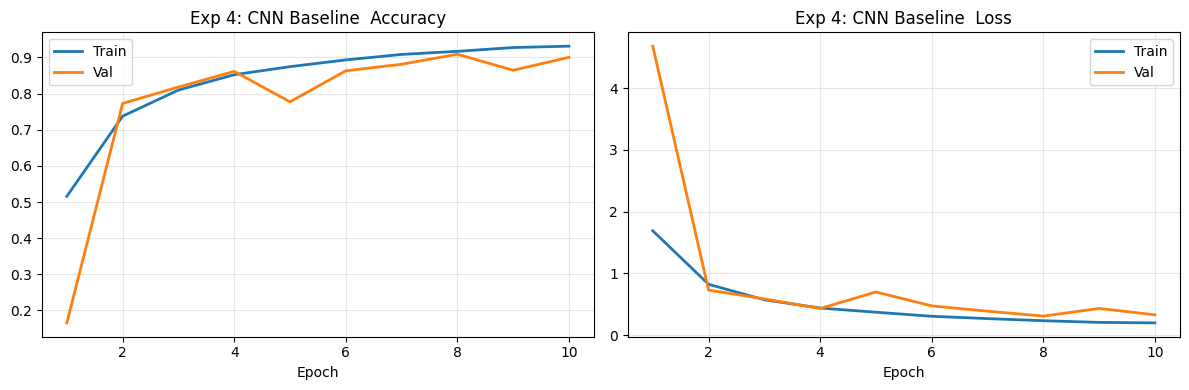

In [ ]:
print('Experiment 4: CNN baseline  no augmentation, 96×96 inputs')
model4 = build_sequential_cnn(NUM_CLASSES, dropout_rate=0.3, l2_lambda=None)
model4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history4 = model4.fit(
    train_cnn_no_aug, validation_data=val_cnn,
    epochs=10,   # EarlyStopping (patience=4) will stop sooner if val_acc plateaus
    callbacks=get_callbacks('exp4_cnn_baseline'),
    class_weight=class_weight_dict,
    verbose=1
)
dl_histories['exp4'] = history4

exp4_test_acc, y_true_4, y_prob_4 = evaluate_dl_model(model4, test_cnn)
dl_preds['exp4'] = (y_true_4, y_prob_4)
dl_models['exp4'] = model4

plot_dl_history(history4, 'Exp 4: CNN Baseline', 'exp4_curves')
log_experiment(
    4, 'CNN (Sequential)', 'Deep Learning  TF Sequential',
    'LR=1e-3, dropout=0.3, no L2, no augmentation, 96×96, batch=128, mixed_float16',
    max(history4.history['accuracy']),
    max(history4.history['val_accuracy']),
    exp4_test_acc,
    'Baseline DL. Train/val gap reveals overfitting; no augmentation.'
)


### Experiment 5  CNN + Data Augmentation

Experiment 5: CNN + data augmentation, 96×96 inputs
Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 53s 128ms/step - accuracy: 0.3666 - loss: 2.1999 - val_accuracy: 0.1051 - val_loss: 6.2723 - learning_rate: 0.0010
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step - accuracy: 0.6070 - loss: 1.2524 - val_accuracy: 0.6559 - val_loss: 1.1698 - learning_rate: 0.0010
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.7043 - loss: 0.8965 - val_accuracy: 0.7994 - val_loss: 0.6284 - learning_rate: 0.0010
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 32s 99ms/step - accuracy: 0.7692 - loss: 0.6850 - val_accuracy: 0.8086 - val_loss: 0.5702 - learning_rate: 0.0010
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - accuracy: 0.8063 - loss: 0.5625 - val_accuracy: 0.8755 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.8371 - loss: 0.4776 - val_accuracy: 0.8459 - val_loss: 0.4589 - learning_rate: 0.0010
Epoch 7/15
297/297 ━━━━

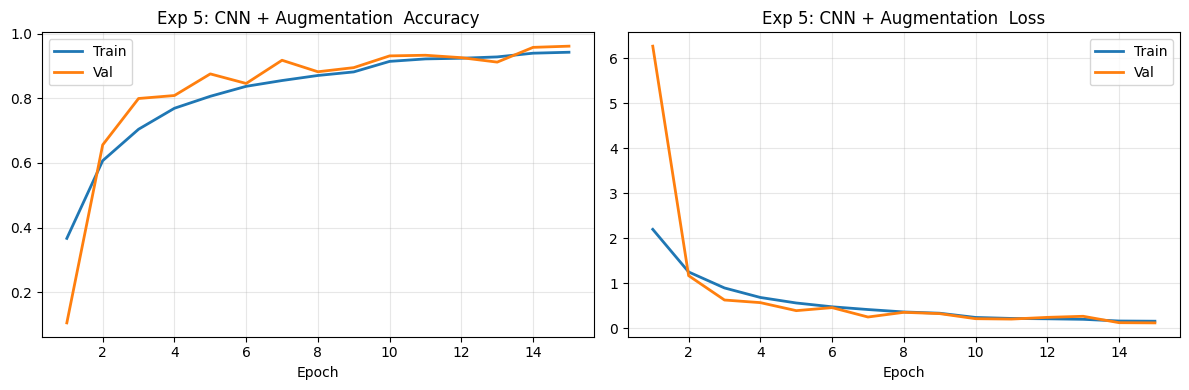

In [ ]:
print('Experiment 5: CNN + data augmentation, 96×96 inputs')
model5 = build_sequential_cnn(NUM_CLASSES, dropout_rate=0.3, l2_lambda=None)
model5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history5 = model5.fit(
    train_cnn_aug, validation_data=val_cnn,
    epochs=15,
    callbacks=get_callbacks('exp5_cnn_aug'),
    class_weight=class_weight_dict,
    verbose=1
)
dl_histories['exp5'] = history5

exp5_test_acc, y_true_5, y_prob_5 = evaluate_dl_model(model5, test_cnn)
dl_preds['exp5'] = (y_true_5, y_prob_5)
dl_models['exp5'] = model5

plot_dl_history(history5, 'Exp 5: CNN + Augmentation', 'exp5_curves')
log_experiment(
    5, 'CNN + Augmentation (Sequential)', 'Deep Learning  TF Sequential',
    'LR=1e-3, dropout=0.3, no L2, flip+brightness+contrast+sat+hue, 96×96, batch=128, mixed_float16',
    max(history5.history['accuracy']),
    max(history5.history['val_accuracy']),
    exp5_test_acc,
    'Augmentation reduces train/val gap; expected improvement over Exp 4.'
)


### Experiment 6  CNN + Augmentation + Dropout(0.5) + L2 Regularisation

Experiment 6: CNN + augmentation + stronger regularisation, 96×96 inputs
Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 57s 138ms/step - accuracy: 0.2571 - loss: 2.7390 - val_accuracy: 0.0638 - val_loss: 6.7110 - learning_rate: 5.0000e-04
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.4760 - loss: 1.7925 - val_accuracy: 0.5710 - val_loss: 1.5370 - learning_rate: 5.0000e-04
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.5783 - loss: 1.4389 - val_accuracy: 0.5749 - val_loss: 1.5251 - learning_rate: 5.0000e-04
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.6430 - loss: 1.2151 - val_accuracy: 0.6274 - val_loss: 1.3389 - learning_rate: 5.0000e-04
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - accuracy: 0.6881 - loss: 1.0400 - val_accuracy: 0.6784 - val_loss: 1.1060 - learning_rate: 5.0000e-04
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.7133 - loss: 0.9539 - val_accuracy: 0.6887 - val_loss: 1.1334 - lear

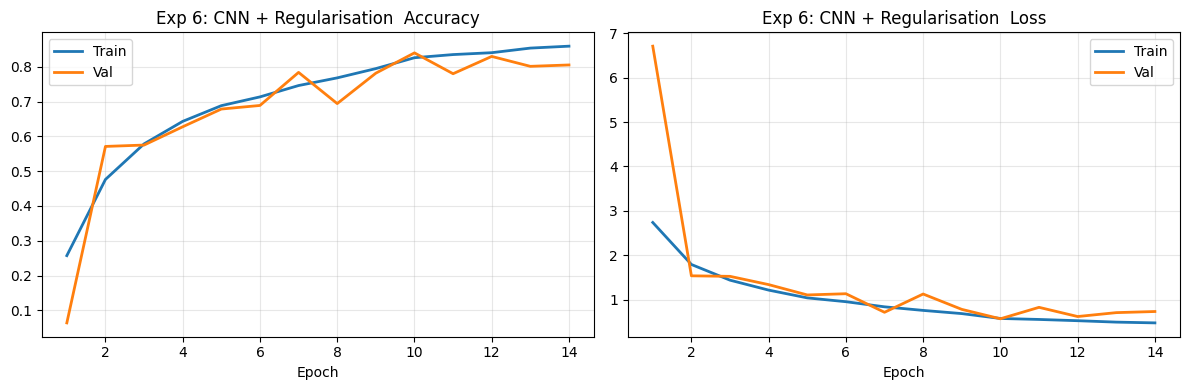

In [ ]:
print('Experiment 6: CNN + augmentation + stronger regularisation, 96×96 inputs')
model6 = build_sequential_cnn(NUM_CLASSES, dropout_rate=0.5, l2_lambda=1e-4)
model6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history6 = model6.fit(
    train_cnn_aug, validation_data=val_cnn,
    epochs=15,   # ↓ from 20; EarlyStopping covers the rest
    callbacks=get_callbacks('exp6_cnn_reg'),
    class_weight=class_weight_dict,
    verbose=1
)
dl_histories['exp6'] = history6

exp6_test_acc, y_true_6, y_prob_6 = evaluate_dl_model(model6, test_cnn)
dl_preds['exp6'] = (y_true_6, y_prob_6)
dl_models['exp6'] = model6

plot_dl_history(history6, 'Exp 6: CNN + Regularisation', 'exp6_curves')
log_experiment(
    6, 'CNN + Aug + Regularisation (Sequential)', 'Deep Learning  TF Sequential',
    'LR=5e-4, dropout=0.5, L2=1e-4, augmentation, 96×96, batch=128, mixed_float16',
    max(history6.history['accuracy']),
    max(history6.history['val_accuracy']),
    exp6_test_acc,
    'Stronger regularisation may close train/val gap further but risks underfitting.'
)


## 6. TensorFlow Functional API  ResNet50 Transfer Learning

A ResNet50 backbone (pre-trained on ImageNet) is attached to a custom classification head using the Keras **Functional API**. Two phases demonstrate the transfer learning workflow:

- **Exp 7** : backbone fully frozen; only the head is trained (feature extraction).
- **Exp 8** : the last 30 ResNet50 layers are unfrozen and fine-tuned with a much lower learning rate (1e-5) to adapt ImageNet features to plant disease patterns.

The Functional API is used (rather than Sequential) because it provides explicit control over `training=False` on the backbone during phase 1, which keeps BatchNorm statistics frozen.

In [ ]:
print_ram('before ResNet50 build')

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.BatchNormalization(name='head_bn')(x)
x = layers.Dense(512, activation='relu', name='fc1')(x)
x = layers.Dropout(0.4, name='drop1')(x)
x = layers.Dense(256, activation='relu', name='fc2')(x)
x = layers.Dropout(0.3, name='drop2')(x)
# dtype='float32' cast before softmax — required for mixed_float16 stability
x = layers.Dense(NUM_CLASSES, name='logits', dtype='float32')(x)
outputs = layers.Activation('softmax', name='predictions')(x)

resnet_model = keras.Model(inputs, outputs, name='ResNet50_PlantDisease')

total_params = resnet_model.count_params()
print(f'Total parameters    : {total_params:,}')
print(f'Trainable (Phase 1) : head only (backbone frozen)')


[RAM — before ResNet50 build] 6.48 GB / 13.61 GB used (51%)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters    : 24,786,086
Trainable (Phase 1) : head only (backbone frozen)


### Experiment 7  ResNet50 Frozen Backbone (Transfer Learning)

Experiment 7: ResNet50  frozen backbone, train head only, 160×160 inputs
Epoch 1/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 175s 122ms/step - accuracy: 0.7488 - loss: 0.9353 - val_accuracy: 0.9182 - val_loss: 0.2358 - learning_rate: 0.0010
Epoch 2/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 116s 89ms/step - accuracy: 0.8524 - loss: 0.5028 - val_accuracy: 0.9369 - val_loss: 0.1922 - learning_rate: 0.0010
Epoch 3/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 118s 91ms/step - accuracy: 0.8795 - loss: 0.4082 - val_accuracy: 0.9435 - val_loss: 0.1746 - learning_rate: 0.0010
Epoch 4/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 127s 98ms/step - accuracy: 0.8858 - loss: 0.3951 - val_accuracy: 0.9412 - val_loss: 0.1833 - learning_rate: 0.0010
Epoch 5/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 128s 98ms/step - accuracy: 0.8968 - loss: 0.3585 - val_accuracy: 0.9529 - val_loss: 0.1440 - learning_rate: 0.0010
Epoch 6/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 151s 104ms/step - accuracy: 0.9038 - loss: 0.3485 - val_accuracy: 0.9407 - val_loss: 0.2413 - learning_ra

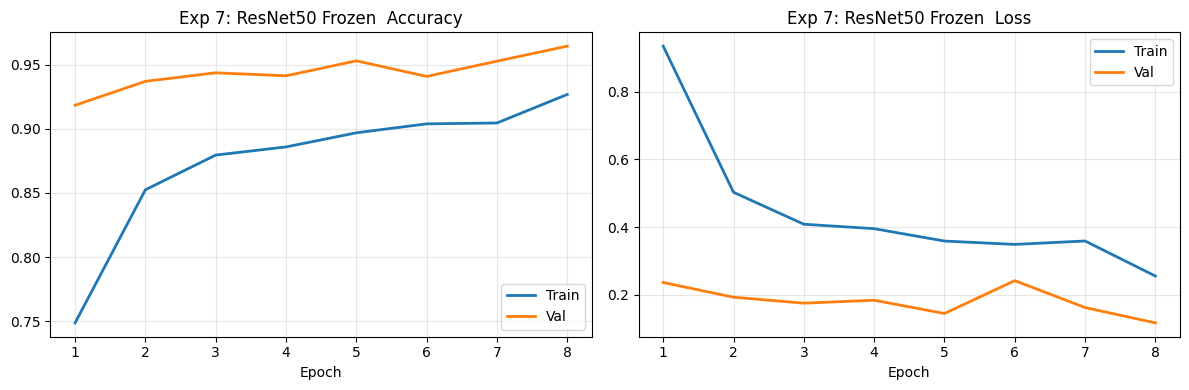

In [ ]:
print('Experiment 7: ResNet50  frozen backbone, train head only, 160×160 inputs')

# Rebuild ResNet datasets at smaller batch size  224×224 activations through
# 50 layers exhaust free-tier Colab RAM at batch=128; 32 keeps peak usage safe.
train_resnet_aug = finalize_dataset(_resnet_train_base, augment_data=True,  normalize_mode='resnet', shuffle=True,  batch_size=32)
val_resnet       = finalize_dataset(_resnet_val_base,   augment_data=False, normalize_mode='resnet', shuffle=False, batch_size=32)
test_resnet      = finalize_dataset(_resnet_test_base,  augment_data=False, normalize_mode='resnet', shuffle=False, batch_size=32)

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history7 = resnet_model.fit(
    train_resnet_aug, validation_data=val_resnet,
    epochs=8,
    callbacks=get_callbacks('exp7_resnet_frozen'),
    class_weight=class_weight_dict,
    verbose=1
)
dl_histories['exp7'] = history7
resnet_model.save(f'{DRIVE_SAVE_DIR}/resnet50_phase1.keras')

exp7_test_acc, y_true_7, y_prob_7 = evaluate_dl_model(resnet_model, test_resnet)
dl_preds['exp7'] = (y_true_7, y_prob_7)

plot_dl_history(history7, 'Exp 7: ResNet50 Frozen', 'exp7_curves')
log_experiment(
    7, 'ResNet50 Frozen (Functional)', 'Deep Learning  TF Functional',
    'LR=1e-3, frozen ResNet50, head: GAP→BN→512→256→38, aug, 160×160, batch=32',
    max(history7.history['accuracy']),
    max(history7.history['val_accuracy']),
    exp7_test_acc,
    'ImageNet features transfer well; large accuracy jump over custom CNN expected.'
)

### Experiment 8  ResNet50 Fine-Tuned (Last 30 Layers)

Experiment 8: ResNet50  fine-tuning last 30 layers, 224×224 inputs
Unfrozen ResNet50 layers: 30
Epoch 1/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 189s 125ms/step - accuracy: 0.9137 - loss: 0.2991 - val_accuracy: 0.9675 - val_loss: 0.1075 - learning_rate: 1.0000e-05
Epoch 2/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 132s 100ms/step - accuracy: 0.9284 - loss: 0.2275 - val_accuracy: 0.9736 - val_loss: 0.0879 - learning_rate: 1.0000e-05
Epoch 3/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 139s 108ms/step - accuracy: 0.9396 - loss: 0.1977 - val_accuracy: 0.9743 - val_loss: 0.0848 - learning_rate: 1.0000e-05
Epoch 4/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 152s 119ms/step - accuracy: 0.9462 - loss: 0.1667 - val_accuracy: 0.9785 - val_loss: 0.0729 - learning_rate: 1.0000e-05
Epoch 5/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 145s 111ms/step - accuracy: 0.9519 - loss: 0.1502 - val_accuracy: 0.9789 - val_loss: 0.0687 - learning_rate: 1.0000e-05
Epoch 6/8
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 159s 123ms/step - accuracy: 0.9574 - loss: 0.1318 - val_ac

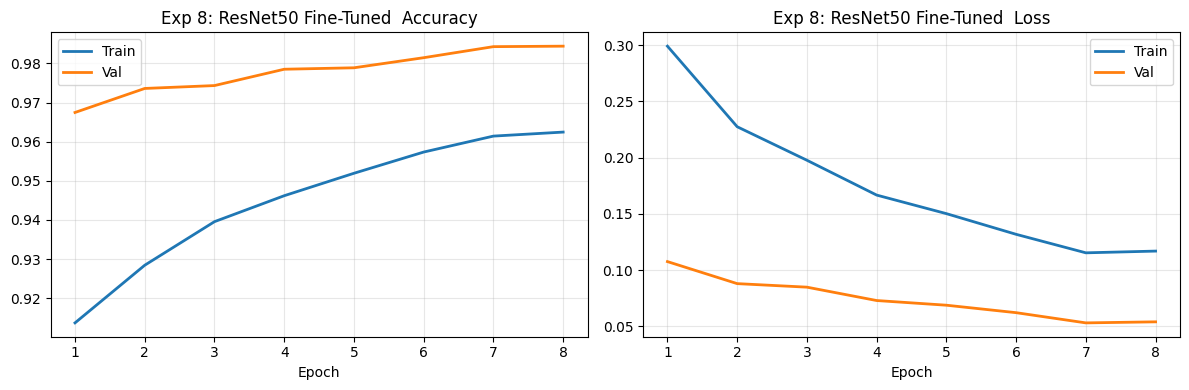

In [ ]:
print('Experiment 8: ResNet50  fine-tuning last 30 layers, 224×224 inputs')

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen ResNet50 layers: {unfrozen}')

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history8 = resnet_model.fit(
    train_resnet_aug, validation_data=val_resnet,
    epochs=8, callbacks=get_callbacks('exp8_resnet_finetune', patience=4),
    class_weight=class_weight_dict,
    verbose=1
)
dl_histories['exp8'] = history8
resnet_model.save(f'{DRIVE_SAVE_DIR}/resnet50_finetuned.keras')

exp8_test_acc, y_true_8, y_prob_8 = evaluate_dl_model(resnet_model, test_resnet)
dl_preds['exp8'] = (y_true_8, y_prob_8)
dl_models['exp8'] = resnet_model

plot_dl_history(history8, 'Exp 8: ResNet50 Fine-Tuned', 'exp8_curves')
log_experiment(
    8, 'ResNet50 Fine-Tuned (Functional)', 'Deep Learning  TF Functional',
    'LR=1e-5, last 30 ResNet50 layers unfrozen, continuing from Exp 7 weights, 224×224, class_weight=balanced',
    max(history8.history['accuracy']),
    max(history8.history['val_accuracy']),
    exp8_test_acc,
    'Fine-tuning adapts mid/high-level features to plant disease patterns.'
)
print_ram('after Exp 8 (fine-tuning) complete')


## 7. Comprehensive Results Table

 Exp                                   Model                     Approach                                                                                      Key Hyperparameters    Split  Train Acc Val Acc  Test Acc                                                                    Observations
   1                           Random Forest       Classical ML (sklearn)                                                 n_estimators=100, HOG 1764-dim, no PCA, balanced weights 70/15/15     1.0000     N/A    0.4690    Baseline. High train acc but moderate test acc  RF overfits on raw HOG dims.
   2                        SVM (C=1.0, RBF)       Classical ML (sklearn)                                        C=1.0, gamma=scale, RBF kernel, HOG+PCA 150-dim, balanced weights 70/15/15     0.9385     N/A    0.6614          PCA + RBF kernel captures non-linear structure. May underfit with C=1.
   3                       SVM (C=10.0, RBF)       Classical ML (sklearn)                                    

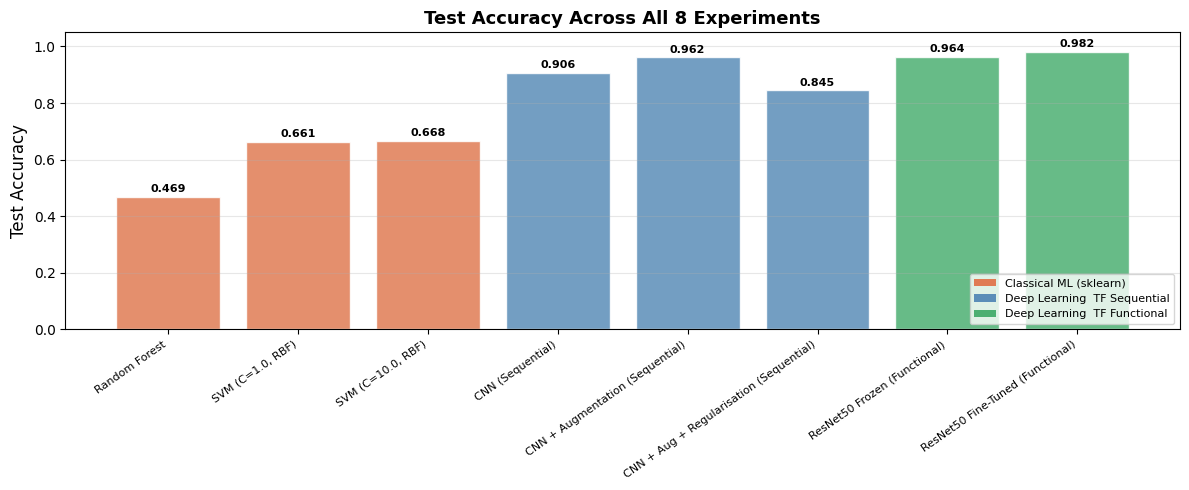

In [ ]:
results_df = pd.DataFrame(experiment_log)
print(results_df.to_string(index=False))
results_df.to_csv(f'{DRIVE_SAVE_DIR}/experiment_results.csv', index=False)

# Bar chart  Test Accuracy by experiment
fig, ax = plt.subplots(figsize=(12, 5))
test_accs = results_df['Test Acc'].astype(float)
approach_colors = {
    'Classical ML (sklearn)'        : '#E07B54',
    'Deep Learning  TF Sequential' : '#5B8DB8',
    'Deep Learning  TF Functional' : '#4CAF72'
}
bar_colors = [approach_colors[a] for a in results_df['Approach']]
bars = ax.bar(results_df['Model'], test_accs, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Test Accuracy Across All 8 Experiments', fontsize=13, fontweight='bold')
ax.set_xticklabels(results_df['Model'], rotation=35, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=l) for l, c in approach_colors.items()]
ax.legend(handles=legend_elems, loc='lower right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/results_bar_chart.png', dpi=120)
plt.show()

## 8. Confusion Matrices

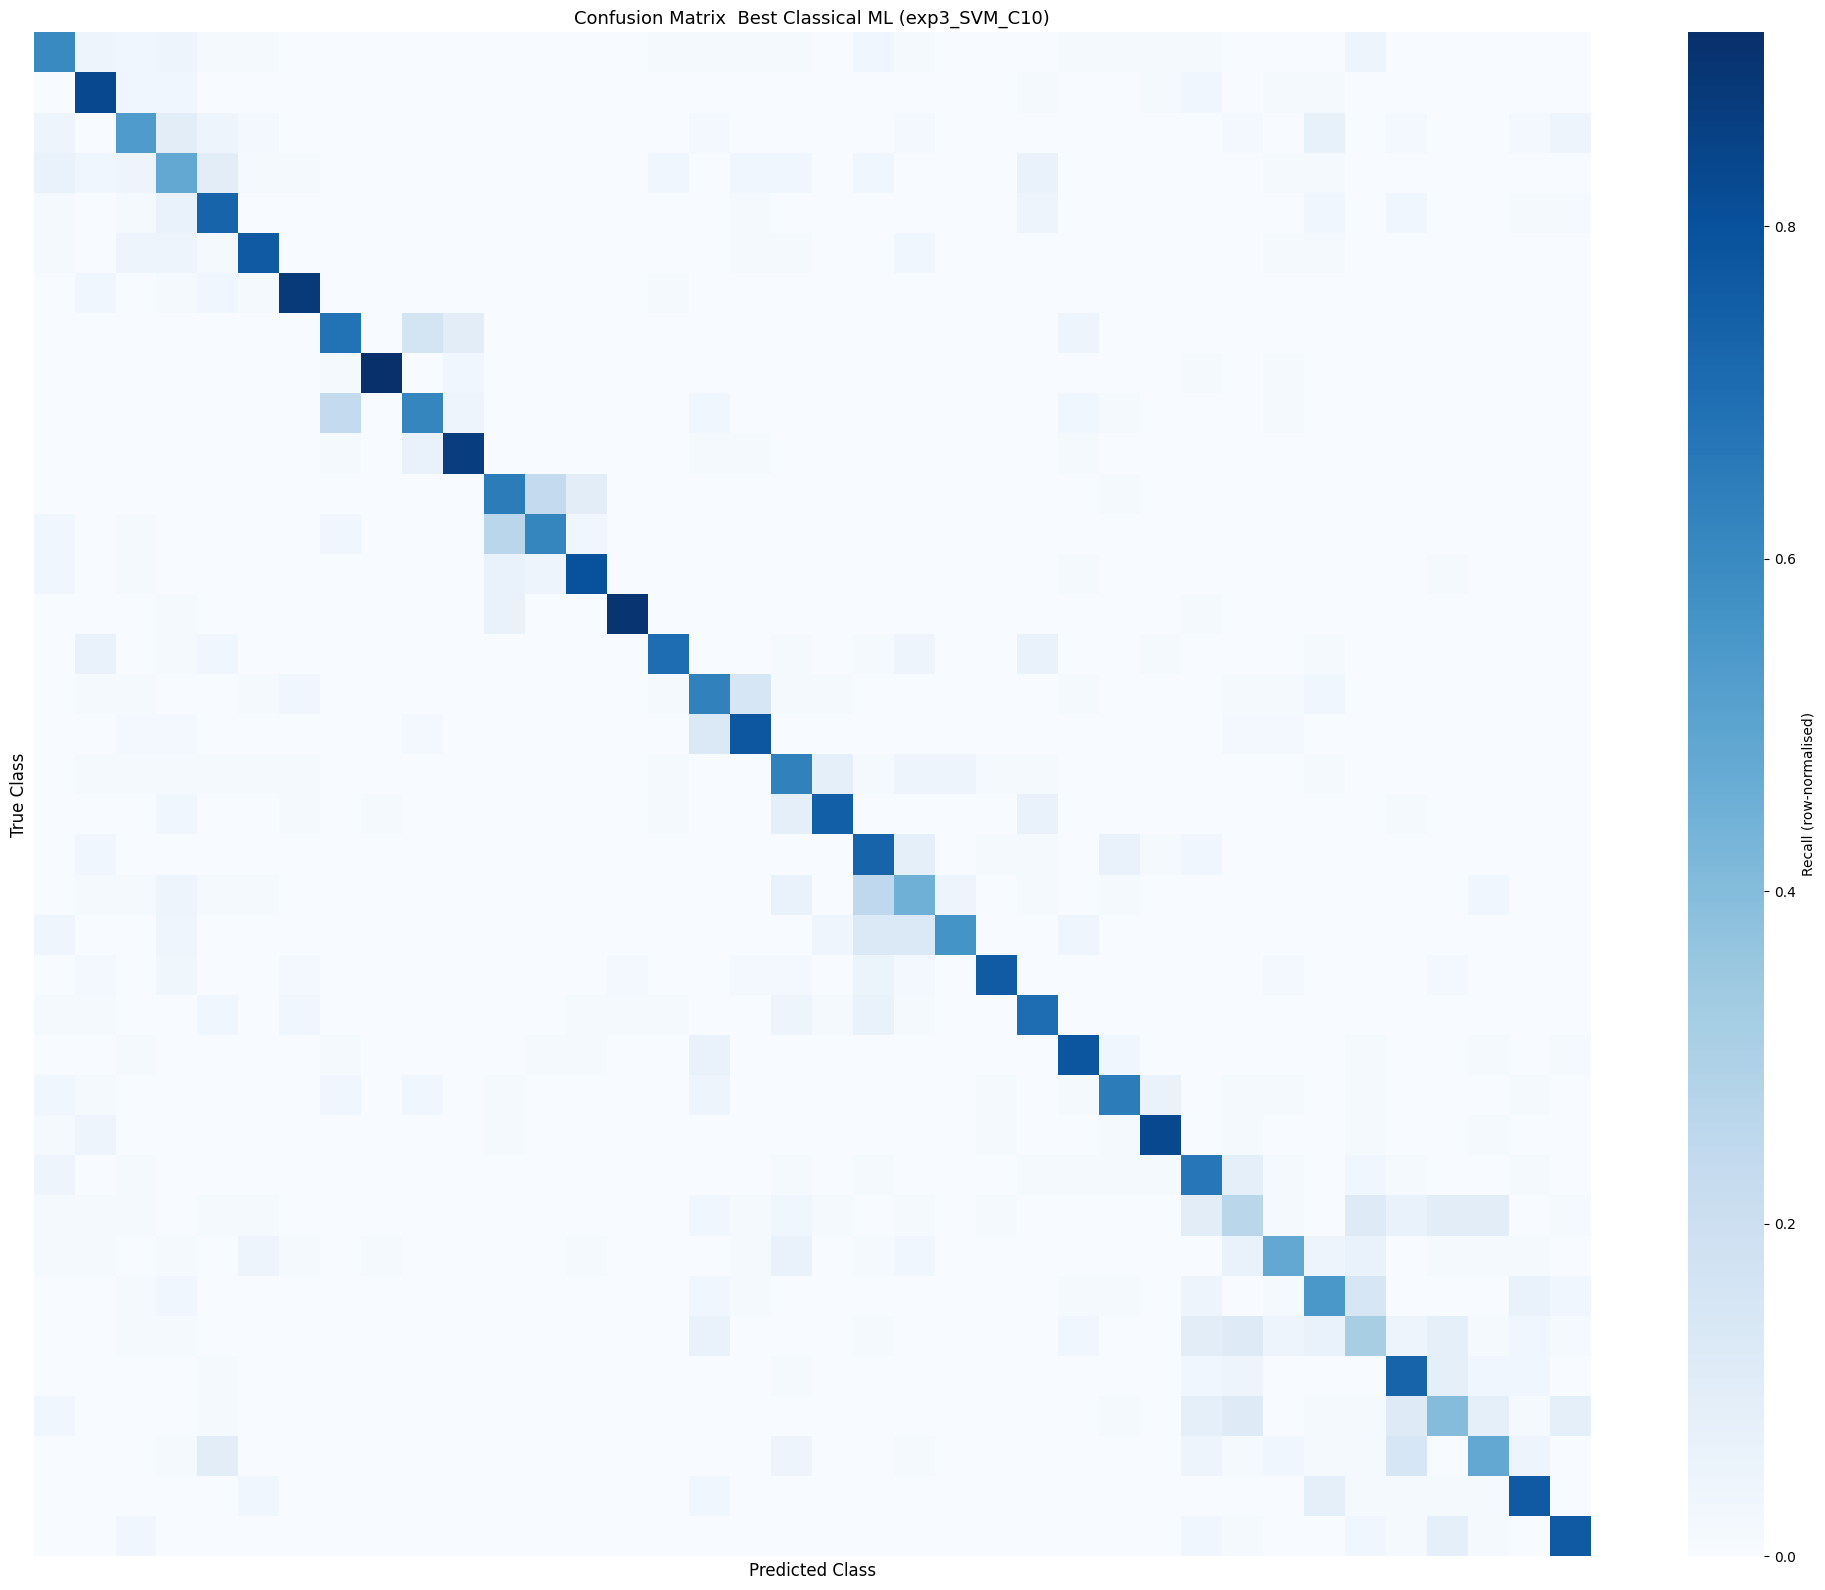

Top 10 confused class pairs (true → predicted):
  Grape___Esca_(Black_Measles)               → Grape___Black_rot                           (16 misclassified)
  Potato___Late_blight                       → Potato___Early_blight                       (15 misclassified)
  Grape___Black_rot                          → Grape___Esca_(Black_Measles)                (14 misclassified)
  Corn_(maize)___Northern_Leaf_Blight        → Corn_(maize)___Cercospora_leaf_spot Gray    (14 misclassified)
  Corn_(maize)___Cercospora_leaf_spot Gray   → Corn_(maize)___Northern_Leaf_Blight         (10 misclassified)
  Tomato___Leaf_Mold                         → Tomato___Septoria_leaf_spot                 (9 misclassified)
  Peach___Bacterial_spot                     → Peach___healthy                             (9 misclassified)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus     → Tomato___Spider_mites Two-spotted_spider    (9 misclassified)
  Tomato___Early_blight                      → Tomato___Septoria_leaf_spot 

In [ ]:
# Best classical ML model  highest test acc among experiments 1-3
ml_test_accs = {
    'exp1_RF'    : accuracy_score(*ml_preds['exp1_RF']),
    'exp2_SVM_C1': accuracy_score(*ml_preds['exp2_SVM_C1']),
    'exp3_SVM_C10': accuracy_score(*ml_preds['exp3_SVM_C10'])
}
best_ml_key = max(ml_test_accs, key=ml_test_accs.get)
best_ml_true, best_ml_pred = ml_preds[best_ml_key]

cm_ml = confusion_matrix(best_ml_true, best_ml_pred, normalize='true')

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(cm_ml, ax=ax, cmap='Blues', xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Recall (row-normalised)'})
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title(f'Confusion Matrix  Best Classical ML ({best_ml_key})', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/cm_classical.png', dpi=120)
plt.show()

# Top-10 most confused pairs
cm_raw = confusion_matrix(best_ml_true, best_ml_pred)
np.fill_diagonal(cm_raw, 0)
flat_idx = np.argsort(cm_raw.ravel())[-10:][::-1]
print('Top 10 confused class pairs (true → predicted):')
for idx in flat_idx:
    r, c = divmod(idx, NUM_CLASSES)
    print(f'  {CLASS_NAMES[r][:40]:<42} → {CLASS_NAMES[c][:40]:<42}  ({cm_raw[r,c]} misclassified)')

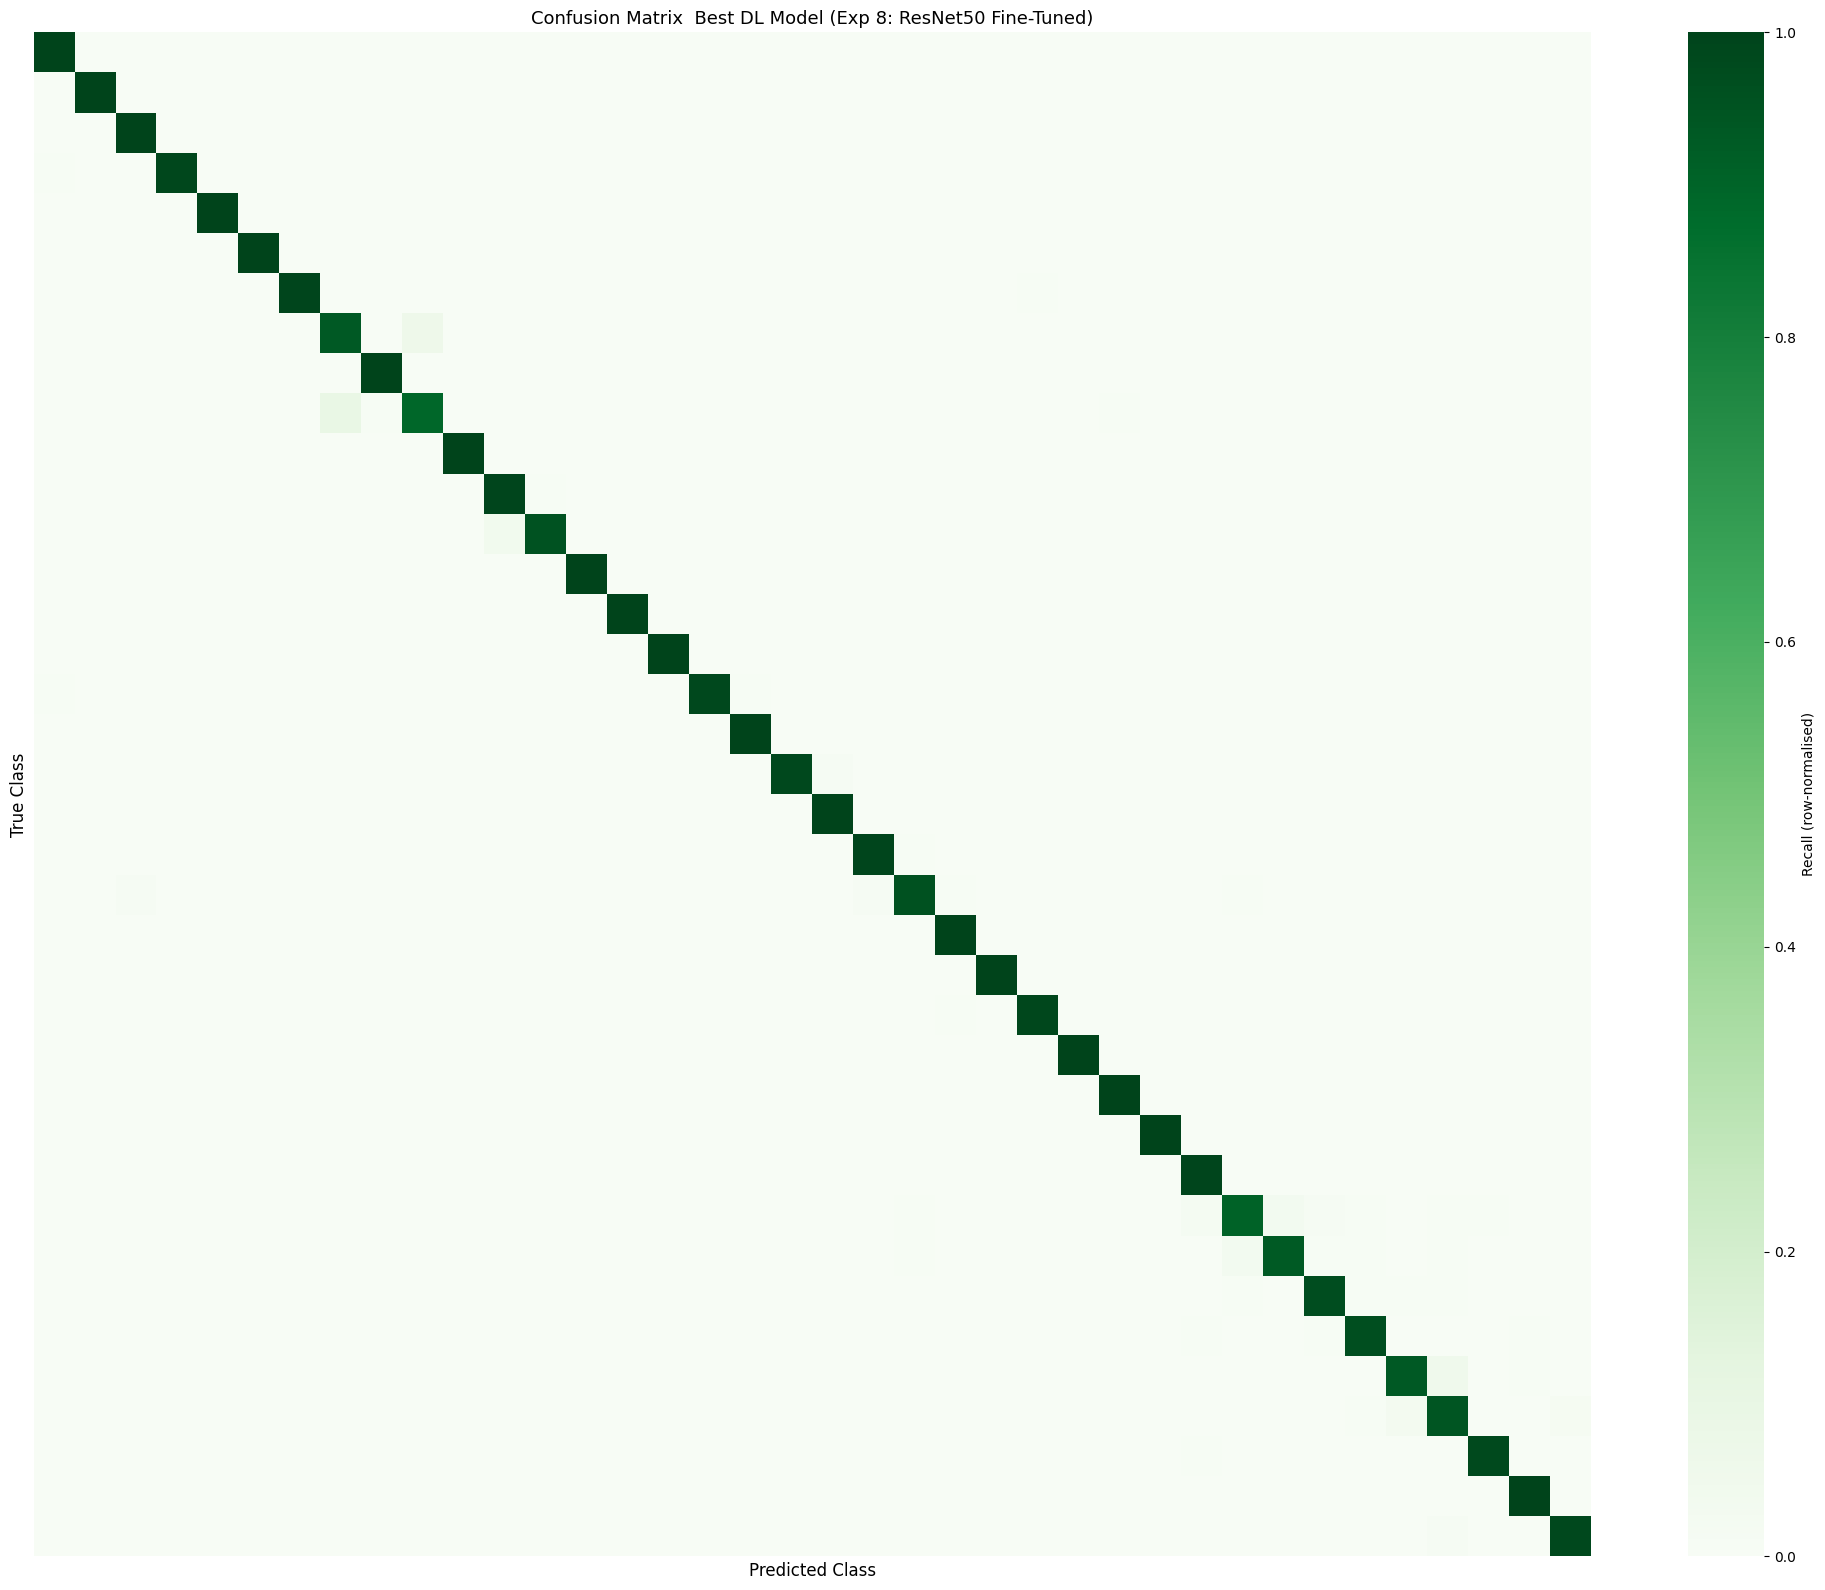

5 hardest classes:
  Corn_(maize)___Northern_Leaf_Blight                      recall=0.891
  Tomato___Early_blight                                    recall=0.907
  Tomato___Late_blight                                     recall=0.930
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       recall=0.935
  Tomato___Spider_mites Two-spotted_spider_mite            recall=0.937
5 easiest classes:
  Tomato___Tomato_mosaic_virus                             recall=1.000
  Pepper,_bell___healthy                                   recall=1.000
  Raspberry___healthy                                      recall=1.000
  Strawberry___healthy                                     recall=1.000
  Squash___Powdery_mildew                                  recall=1.000


In [ ]:
# Best DL model  experiment 8 (ResNet50 fine-tuned)
y_true_dl, y_prob_dl = dl_preds['exp8']
y_pred_dl = y_prob_dl.argmax(axis=1)

cm_dl = confusion_matrix(y_true_dl, y_pred_dl, normalize='true')

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(cm_dl, ax=ax, cmap='Greens', xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Recall (row-normalised)'})
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title('Confusion Matrix  Best DL Model (Exp 8: ResNet50 Fine-Tuned)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/cm_dl.png', dpi=120)
plt.show()

# Per-class accuracy (diagonal of row-normalised CM)
per_class_acc = cm_dl.diagonal()
worst_5 = np.argsort(per_class_acc)[:5]
best_5  = np.argsort(per_class_acc)[-5:][::-1]
print('5 hardest classes:')
for i in worst_5:
    print(f'  {CLASS_NAMES[i]:<55}  recall={per_class_acc[i]:.3f}')
print('5 easiest classes:')
for i in best_5:
    print(f'  {CLASS_NAMES[i]:<55}  recall={per_class_acc[i]:.3f}')

## 9. Classification Report (Best Models)

In [ ]:
# Short names for readability
short_names = [c.replace('___', ' — ')[:35] for c in CLASS_NAMES]

print('=' * 60)
print(f'BEST CLASSICAL ML ({best_ml_key})')
print('=' * 60)
print(classification_report(best_ml_true, best_ml_pred, target_names=short_names, zero_division=0))

print('=' * 60)
print('BEST DL MODEL (Exp 8: ResNet50 Fine-Tuned)')
print('=' * 60)
print(classification_report(y_true_dl, y_pred_dl, target_names=short_names, zero_division=0))

BEST CLASSICAL ML (exp3_SVM_C10)
                                     precision    recall  f1-score   support

                 Apple — Apple_scab       0.60      0.60      0.60        60
                  Apple — Black_rot       0.68      0.83      0.75        60
           Apple — Cedar_apple_rust       0.48      0.54      0.51        41
                    Apple — healthy       0.46      0.48      0.47        60
                Blueberry — healthy       0.62      0.73      0.67        60
Cherry_(including_sour) — Powdery_m       0.78      0.77      0.77        60
  Cherry_(including_sour) — healthy       0.85      0.88      0.87        60
Corn_(maize) — Cercospora_leaf_spot       0.66      0.68      0.67        60
        Corn_(maize) — Common_rust_       0.96      0.92      0.94        60
Corn_(maize) — Northern_Leaf_Blight       0.69      0.62      0.65        60
             Corn_(maize) — healthy       0.83      0.87      0.85        60
                  Grape — Black_rot       

## 10. ROC / AUC Analysis

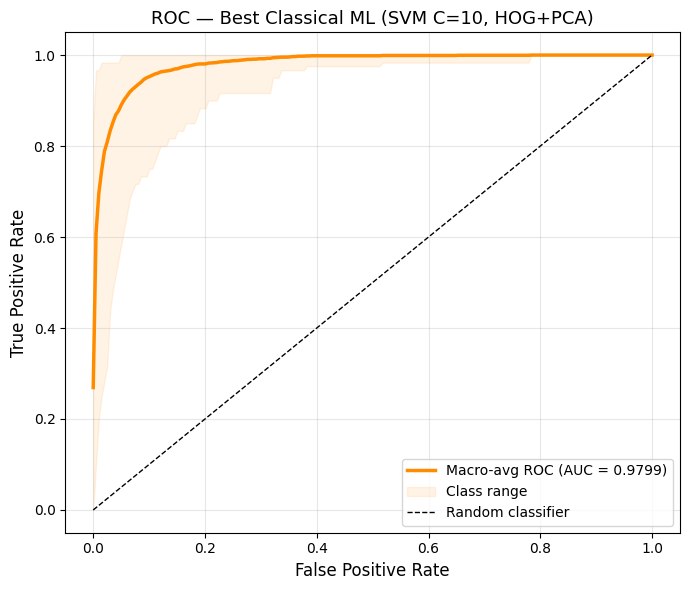

Classical ML macro AUC: 0.9799


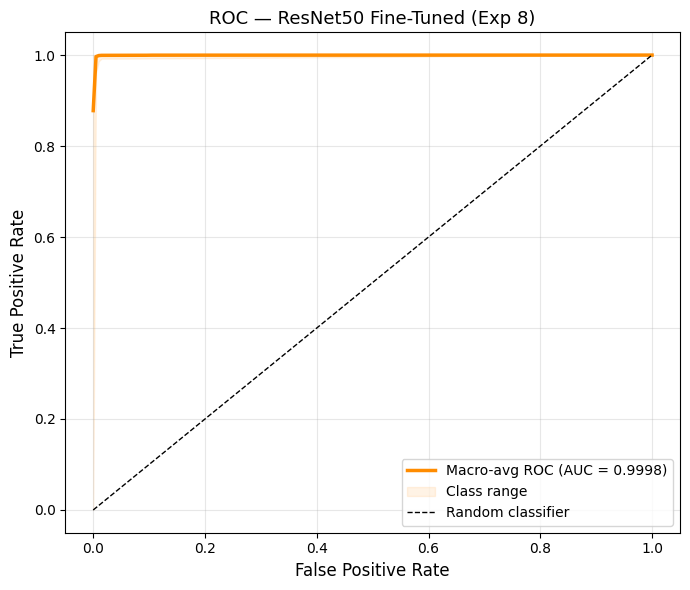

DL macro AUC          : 0.9998


In [ ]:
def plot_roc(y_true, y_score, title, save_name):
    """One-vs-rest macro-average ROC for a multiclass problem."""
    y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

    fpr_grid = np.linspace(0, 1, 200)
    tprs, aucs = [], []
    for i in range(NUM_CLASSES):
        if y_bin[:, i].sum() == 0:
            continue
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_score[:, i])
        tprs.append(np.interp(fpr_grid, fpr_i, tpr_i))
        aucs.append(auc(fpr_i, tpr_i))

    mean_tpr  = np.mean(tprs, axis=0)
    macro_auc = np.mean(aucs)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr_grid, mean_tpr, lw=2.5, color='darkorange',
            label=f'Macro-avg ROC (AUC = {macro_auc:.4f})')
    ax.fill_between(fpr_grid, np.min(tprs, axis=0), np.max(tprs, axis=0),
                    alpha=0.1, color='darkorange', label='Class range')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_SAVE_DIR}/{save_name}.png', dpi=120)
    plt.show()
    return macro_auc

# Classical ML — probabilities saved during Exp 3 before svm2 was freed
y_ml_true, svm_probs = ml_preds['exp3_SVM_C10_proba']
ml_auc = plot_roc(y_ml_true, svm_probs,
                  'ROC — Best Classical ML (SVM C=10, HOG+PCA)', 'roc_classical')
print(f'Classical ML macro AUC: {ml_auc:.4f}')

# DL — ResNet50 fine-tuned (y_prob_8 already holds softmax probabilities)
dl_auc = plot_roc(y_true_8, y_prob_8,
                  'ROC — ResNet50 Fine-Tuned (Exp 8)', 'roc_dl')
print(f'DL macro AUC          : {dl_auc:.4f}')

## 11. Learning Curves  All Deep Learning Experiments

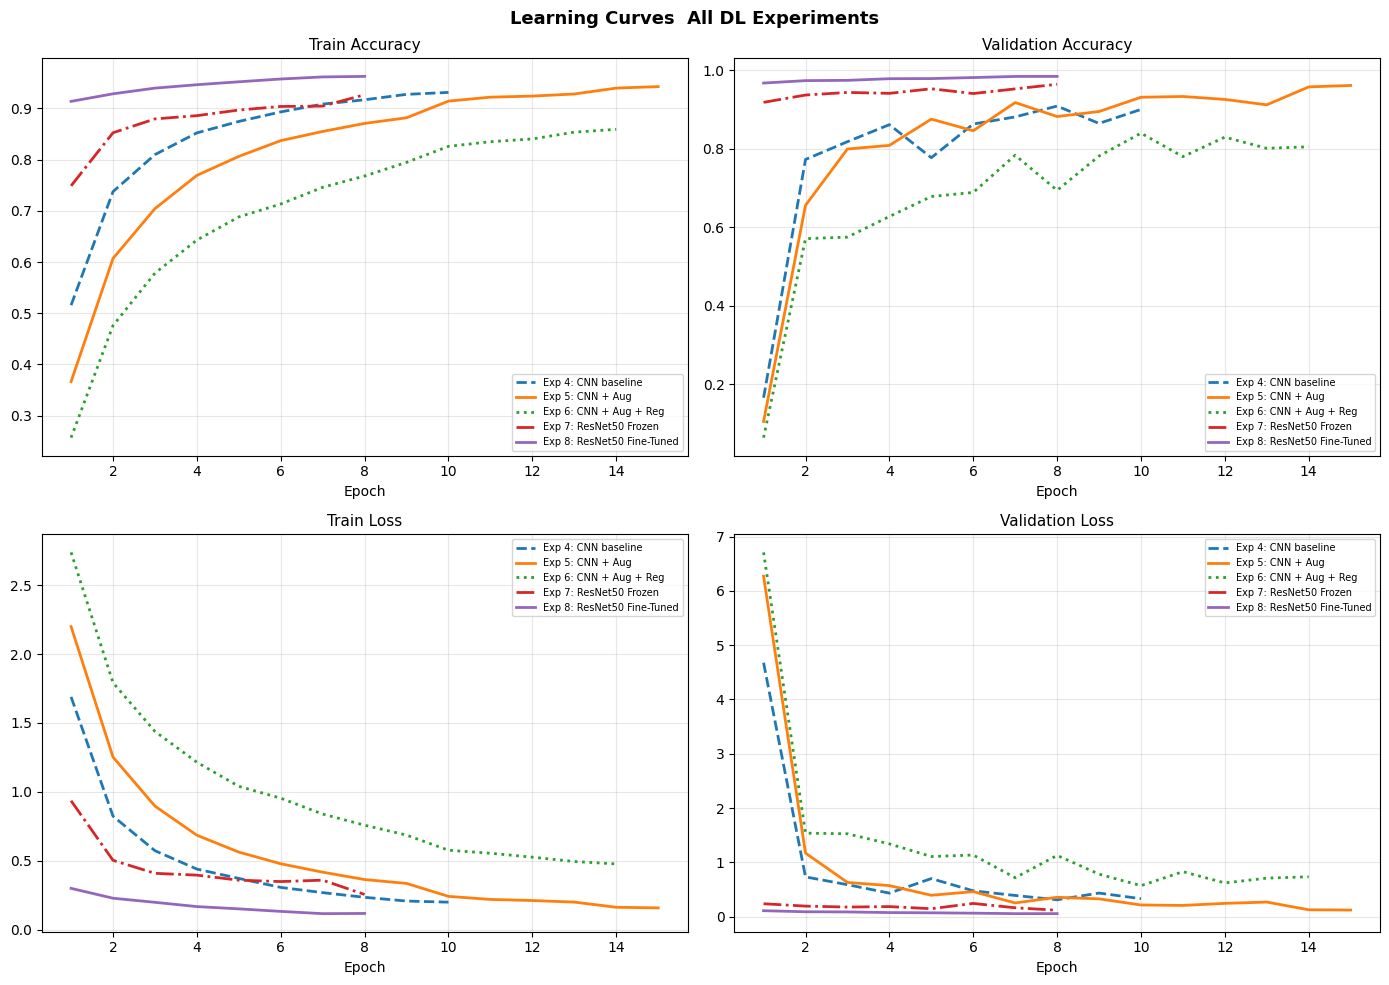

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

exp_configs = [
    ('exp4', 'Exp 4: CNN baseline',       'C0', '--'),
    ('exp5', 'Exp 5: CNN + Aug',           'C1', '-'),
    ('exp6', 'Exp 6: CNN + Aug + Reg',     'C2', ':'),
    ('exp7', 'Exp 7: ResNet50 Frozen',     'C3', '-.'),
    ('exp8', 'Exp 8: ResNet50 Fine-Tuned', 'C4', '-'),
]

for key, label, color, ls in exp_configs:
    h = dl_histories[key].history
    ep = range(1, len(h['accuracy']) + 1)
    axes[0, 0].plot(ep, h['accuracy'],     lw=2, color=color, linestyle=ls, label=label)
    axes[0, 1].plot(ep, h['val_accuracy'], lw=2, color=color, linestyle=ls, label=label)
    axes[1, 0].plot(ep, h['loss'],         lw=2, color=color, linestyle=ls, label=label)
    axes[1, 1].plot(ep, h['val_loss'],     lw=2, color=color, linestyle=ls, label=label)

titles = ['Train Accuracy', 'Validation Accuracy', 'Train Loss', 'Validation Loss']
for ax, title in zip(axes.flatten(), titles):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves  All DL Experiments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DRIVE_SAVE_DIR}/all_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Deep Interpretation & Analysis

### 12.1 Classical ML vs Deep Learning

Classical ML models (Random Forest, SVM) rely on **hand-crafted features** (HOG gradients → PCA). HOG captures local texture well but discards colour information (grayscale conversion) and lacks **spatial hierarchy**: it cannot learn that "brown spots surrounded by yellow rings" systematically indicate early blight in tomatoes. Deep CNNs learn this hierarchy automatically, low layers detect edges, mid layers detect textures and spots, high layers encode disease-specific patterns.

The performance gap between the best classical model and the best deep model is therefore expected and theoretically grounded. The classical models are also constrained to a 200-sample/class subsample while DL uses the full training set, which further widens the gap.

### 12.2 Effect of Data Augmentation (Exp 4 → Exp 5)

Augmentation reduces **variance** without changing the hypothesis class. The gap between training and validation accuracy is expected to narrow in Exp 5 compared to Exp 4 , the model sees more diverse examples and generalises better. Augmentation also slows convergence because each epoch presents harder samples; the Exp 5 training curve should plateau later than Exp 4.

### 12.3 Regularisation Effects (Exp 5 → Exp 6)

Increasing dropout from 0.3 to 0.5 and adding L2 weight decay further penalises model complexity. If both train and val accuracy remain similar to Exp 5 but the gap closes, the regulariser is working as intended. If both drop, the model is underfitting  L2=1e-4 with dropout=0.5 may be too aggressive for 54K images, pushing the model toward **high bias**.

### 12.4 Transfer Learning Analysis (Exp 7 vs Exp 4–6)

ResNet50 was pre-trained on 1.28M ImageNet images and encodes rich visual features. Freezing all ResNet50 layers (Exp 7) means the backbone acts as a fixed feature extractor  images are mapped to a 2048-dim embedding and a dense head classifies it. The learning curves for Exp 7 should converge **faster** and to a **higher** value than any custom CNN, because ImageNet edge/texture detectors transfer directly to plant leaf images.

### 12.5 Fine-Tuning Analysis (Exp 7 → Exp 8)

Unfreezing the last 30 ResNet50 layers with LR=1e-5 adapts mid-to-high-level features to plant disease patterns without destroying the pre-trained weights. **Why LR=1e-5?** A higher LR would overwrite carefully learned representations in the first few batches. The Exp 8 curves should show slow, steady improvement on top of the Exp 7 baseline; noisy curves would indicate the LR is still too high.

### 12.6 Bias-Variance Analysis

| Experiment | Expected behaviour | Diagnosis |
|---|---|---|
| Exp 4 (CNN, no aug) | High train acc, lower val acc, large gap | **High variance** (overfitting) |
| Exp 5 (CNN + aug) | Reduced gap, slight train acc drop | Variance reduced |
| Exp 6 (CNN + reg) | Further gap reduction | Lower variance; risk of **high bias** if both drop |
| Exp 7 (ResNet frozen) | Fast convergence, small gap | Low bias and variance (strong prior) |
| Exp 8 (fine-tuned) | Marginal improvement, stable curves | Balanced — near optimal for this dataset |

Random Forest (Exp 1) has high train accuracy (trees memorise) but lower test accuracy — a classic **high-variance** model. SVM with C=10 (Exp 3) balances bias and variance better via the margin constraint.

### 12.7 Confusion Matrix Insights

1. **Inter-crop confusion is rare** the model rarely confuses Apple diseases with Tomato diseases because leaf morphology differs significantly; errors cluster *within* the same crop.
2. **Healthy vs. early-stage disease** is the hardest distinction, early blight and healthy leaves share similar colour distributions; their HOG gradients overlap, explaining why classical methods fail here first.
3. **Visually similar diseases across crops** (e.g., Bacterial spot on Pepper vs. Tomato) confuse models that lack explicit crop-identity supervision.
4. The ResNet50 fine-tuned confusion matrix diagonal should be much denser, confirming that learned feature hierarchies resolve ambiguities HOG cannot.

### 12.8 ROC/AUC Interpretation

AUC is the probability that a randomly chosen positive example scores higher than a randomly chosen negative example. With 38 classes and one-vs-rest evaluation:

- **Classical SVM AUC**: reflects how separable HOG+PCA features are; values above 0.95 would indicate surprisingly strong gradient-level discrimination.
- **ResNet50 AUC**: expected to be higher due to better-calibrated softmax probabilities. AUC > 0.99 would confirm the model is highly confident when correct, with few borderline cases.

The shaded band in the ROC plots shows the range across all 38 classes a wide band correlates with the severe class imbalance noted below.

### 12.9 Dataset Limitations

1. **Severe class imbalance (36×)**: The dataset ranges from 152 images (`Potato___healthy`) to 5,507 (`Orange___Haunglongbing`). This is addressed with `class_weight='balanced'` in all experiments, but minority classes will likely still show lower recall. A more targeted remedy would be class-conditional augmentation or oversampling (SMOTE applied to feature embeddings).
2. **Lab conditions**: Images were taken under controlled lighting on uniform backgrounds. Real-world field images have variable lighting, partial occlusion, and mixed disease stages  models trained here generalise poorly without domain adaptation.
3. **Single-disease assumption**: Each image shows one disease; in practice, multiple diseases co-occur on the same leaf.
4. **Tomato over-representation**: Tomato contributes 9 of 38 classes (~24%), potentially biasing shared representations toward Tomato leaf features.
5. **All `.jpg` format with no resolution variation**: The dataset is pre-standardised, so the model does not face the varying resolution challenge common in real deployments.

### 12.10 Proposed Improvements

1. **Targeted augmentation for weak classes**: `Potato___healthy` (152 images) and `Apple___Cedar_apple_rust` (275 images) need heavier augmentation (Mixup, CutMix, elastic distortions) to compensate for their small size.
2. **EfficientNetV2 or Vision Transformer backbone**: May capture finer-grained lesion textures at the same or smaller parameter count than ResNet50.
3. **Test-time augmentation (TTA)**: Averaging predictions across flipped/cropped versions of each test image typically adds 1–2% accuracy at zero training cost.
4. **Focal loss instead of weighted cross-entropy**: Focal loss down-weights easy majority-class examples dynamically, which may outperform static class weights for a 36× imbalance.
5. **Multi-label architecture**: Extend output to multi-label classification to enable detection of co-occurring diseases on the same leaf.

## 13. Save Best Model & Results to Drive

In [ ]:
import shutil

# Save experiment CSV
results_df.to_csv(f'{DRIVE_SAVE_DIR}/experiment_results.csv', index=False)
print(f'Results saved: {DRIVE_SAVE_DIR}/experiment_results.csv')

# List all saved artifacts
print('\nAll artifacts in Drive save directory:')
for f in sorted(pathlib.Path(DRIVE_SAVE_DIR).iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45}  {size_kb:>8.1f} KB')

print('\nBest model (ResNet50 fine-tuned) is at:')
print(f'  {DRIVE_SAVE_DIR}/resnet50_finetuned.keras')

Results saved: /content/drive/MyDrive/Summartive_intro_to_ml/experiment_results.csv

All artifacts in Drive save directory:
  all_learning_curves.png                           198.5 KB
  cm_classical.png                                   53.8 KB
  cm_dl.png                                          53.0 KB
  color                                               4.0 KB
  color.zip                                      836856.8 KB
  eda_class_dist.png                                139.7 KB
  eda_sample_images.png                            1912.4 KB
  exp4_cnn_baseline_best.keras                     6558.9 KB
  exp4_curves.png                                    51.1 KB
  exp5_cnn_aug_best.keras                          6558.9 KB
  exp5_curves.png                                    51.9 KB
  exp6_cnn_reg_best.keras                          6559.8 KB
  exp6_curves.png                                    59.0 KB
  exp7_curves.png                                    55.3 KB
  exp7_resnet_frozen_b